# Figure 2 — simulation results

A clean rewrite of `figure2_revision.ipynb`.

**How to use it.** Say which parameters you want; the notebook finds the files.

```r
m <- build_manifest()                       # what is on disk, and with what settings
d <- load_sims(sim_category = 'A',          # -> list(enloc, traits, leads, vars, manifest)
               gwas_mult = 5, gtex_mult = 20,
               causal_min_maf = 0.001, fm_min_maf = 0.01)
plot_enloc_outcomes(d, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_prc(d)                                 # precision-recall across RCP cutoffs
generate_simulation_report(d)               # two-page PDF summary of the arm
```

Nothing is hardcoded to one arm: the species prefix (`h`/`c`), the phenotype
scalings, the causal-MAF floor and the panel inventory are all read off the files,
and the fine-mapping floor, GLM floor and LD threshold off the arm directory name
and `PROVENANCE.txt`.

**Restricting to loci a real GWAS would find.** `add_gwas_significance(d, n)` flags each
causal variant that would reach p < 5e-8 in a study of `n` individuals, computed from the
simulated effect size and allele frequency alone. Every plot function also takes
`gwas_n =` as a shorthand for the same restriction.

**What changed from `figure2_revision.ipynb`** (which is left untouched):

- `get_dfs()` assumed the nested `<base>/<CAT>/<CAT><i>` layout; every current arm is
  flat (`<base>/<CAT><i>`), which is why its last cell errored.
- `read_traits()` globbed `gwas_scaling_35_pheno.sbams`, so it only ever worked on 35x
  arms. The scaling now comes from the manifest, and only column 2 of the sbams file is
  read (~210 MB of phenotype matrices no longer parsed).
- `paste0(sim_category, str(i))` — R's `str()` prints and returns `NULL`, so `sim` was
  `"A"` for *every* replicate and `group_by(gwas, sim)` merged them. Runs are now keyed
  on `run_id`.
- `read_lead_snps()` derived `category` from `gsub('_.*','',file)`, which returns a
  truncated absolute O2 path now that plink's column 1 is a full path.
- The `m4` branch is gone: `m4_marks.tsv` exists nowhere under `simulation_data/`, and
  the positive-selection categories F and G have no fetched data. It also contained a
  call to `cowplot(...)`, which is not a function.
- ~200 lines of commented-out copy-paste, two cells referencing an undefined `eenloc`,
  and ~25 ad-hoc exploration cells removed.

## Setup

In [ ]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)
library(cowplot)
suppressPackageStartupMessages(library(data.table))

fig_size = function(width, heigth){
    options(repr.plot.width = width, repr.plot.height = heigth)
}

# base R gains %||% in 4.4; define it so this runs on 4.3 too
if (!exists('%||%')) `%||%` = function(a, b) if (is.null(a)) b else a

color_key = list(
    'human gwas' = 'lightpink1',
    'human eqtls' = 'firebrick1',
    'human coloc' = 'firebrick4',
    'pig gwas' = 'lightskyblue1',
    'pig eqtls' = 'royalblue1',
    'pig coloc' = 'navyblue',
    'cattle gwas' = 'mediumpurple1',
    'cattle eqtls' = 'purple',
    'cattle coloc' = 'purple4',
    'human' = 'firebrick1',
    'pig' = 'royalblue1',
    'cattle' = 'purple',
    # Per-CATEGORY colours, used when a report groups by simulation category
    # instead of by species (generate_category_report). A/B/C/D/H keep the human
    # red family and E/F/G/I the cattle purple family, so the two-species reports
    # and the category one read the same way. B and H are the two neutral human
    # models and sit next to each other in the ramp; I is H's cattle counterpart
    # and takes the pale end of the purple ramp for the same reason H takes the
    # pale end of the red one.
    'A coloc' = 'firebrick4',
    'B coloc' = 'darksalmon',
    'C coloc' = 'indianred4',
    'D coloc' = 'lightsalmon2',
    'H coloc' = 'salmon3',
    'E coloc' = 'purple4',
    'F coloc' = 'darkorchid3',
    'G coloc' = 'plum3',
    'I coloc' = 'mediumorchid4',
    'J coloc' = 'brown3',   'K coloc' = 'tomato3',
    'L coloc' = 'orchid4',
    # M and N are the Wang-2014 Finnish founder pair and are read together,
    # so they take two neighbouring reds rather than two arbitrary ones.
    'M coloc' = 'coral3',    'N coloc' = 'rosybrown3',
    # O and P are A's and E's genomes with pi halved, so they sit next to their
    # parents in each ramp -- the pairing is the whole content of the contrast.
    'O coloc' = 'firebrick2',
    'P coloc' = 'darkorchid4',
    'A' = 'firebrick4',
    'B' = 'darksalmon',
    'C' = 'indianred4',
    'D' = 'lightsalmon2',
    'H' = 'salmon3',
    'E' = 'purple4',
    'F' = 'darkorchid3',
    'G' = 'plum3',
    'I' = 'mediumorchid4',
    'J' = 'brown3', 'K' = 'tomato3', 'L' = 'orchid4',
    'M' = 'coral3', 'N' = 'rosybrown3',
    'O' = 'firebrick2', 'P' = 'darkorchid4'
)

# What each category letter means, for the key printed on the category report.
CATEGORY_LABEL = c(
    A = 'A  human, directional (negative) selection on trait variants',
    B = 'B  human, NEUTRAL trait variants',
    C = 'C  human, 100k GWAS / 50k GTEx',
    D = 'D  human, 100k GWAS / 50k GTEx, neutral trait variants',
    E = 'E  cattle baseline (bottlenecked)',
    F = 'F  cattle, positive selection, WITH continued bottlenecking',
    G = 'G  cattle, positive selection, WITHOUT bottlenecking',
    # The two neutral models are NOT interchangeable. B keeps a genome produced
    # by a forward run under selection and moves each donor's coefficient onto a
    # neutral variant, so its genealogy still carries background selection. H has
    # no selection anywhere: stage 1 is a pure coalescent and the effect-size
    # parameters are drawn from the DFE with its neutral class removed. B - A
    # isolates the effect assignment; H - A isolates the genealogy.
    # I is H with the cattle demography, and the DFE they draw from is the SAME
    # one -- human_simulation_o2.py and farm_selection.slim define identical
    # components. So H - I isolates the demography, and I - E isolates the
    # genealogy on the cattle side exactly as H - A does on the human side.
    # Unlike E/F/G, I simulates all twelve epochs rather than resuming from the
    # shared ep7 checkpoint -- a coalescent needs no burn-in.
    H = 'H  human, NEUTRAL genealogy (coalescent), drawn DFE effect sizes',
    I = 'I  cattle, NEUTRAL genealogy (coalescent), drawn DFE effect sizes',
    # J is A with the AFR branch of OutOfAfrica_2T12 sampled instead of the
    # EUR one -- same model, same DFE, same selection, same stages 2-5. Where
    # B - A isolates the effect assignment and H - A the genealogy, J - A
    # isolates ANCESTRY: the LD and allele-frequency structure that
    # colocalization power actually depends on. It keeps the human red family
    # (brown3) rather than joining the salmons, because unlike B/C/D/H it is
    # not a variant of the effect model -- it is A, elsewhere.
    J = 'J  human (African ancestry), directional (negative) selection',
    # K and L are the background-selection pair: A's and E's genomes, whose
    # genealogies carry background selection, with H's and I's effect model on
    # top -- causal loci drawn from the NEUTRAL variants, betas from the DFE.
    # They are the cell A - H confounds: K - H is the genealogy alone, A - K
    # the effect assignment alone. K keeps the human red family and L the
    # cattle purple one, as every other pair does.
    K = 'K  human, BACKGROUND selection (neutral causal loci, drawn betas)',
    L = 'L  cattle, BACKGROUND selection (neutral causal loci, drawn betas)',
    # M and N run the Wang et al. 2014 NFE+Finnish model -- a demes graph in
    # simulations/demography/, not an stdpopsim catalog model. Both sample
    # from the SAME run at Q_scaling 3 (forced: the FIN deme holds only 3,446
    # individuals at Q=10, against the 9,000 stage 1 draws). Read them as a
    # pair: M - N is the Finnish founder event with the model held fixed,
    # N - A is the model swap (Wang NFE vs Tennessen EUR) with the founder
    # event held out. M vs A alone confounds the two.
    M = 'M  human (Finnish founder), directional (negative) selection',
    N = 'N  human (non-Finnish European), directional (negative) selection',
    # O and P are the LOW-HETEROZYGOSITY pair. They are A's and E's own tree
    # sequences, at A's and E's own seeds, with a measured fraction of the
    # selco == 0 sites deleted in stage 2 -- sized so pi halves. Only neutral
    # sites are touched, and every causal predicate selects on selco != 0, so
    # the 50 central loci, the flank loci and the effect sizes are IDENTICAL to
    # the parent category's. O{N}'s variant set is a strict SUBSET of A{N}'s.
    # A - O and E - P therefore isolate variant density, with no replicate noise
    # in the way, which no other pair on this axis does.
    # Caveat to quote alongside any O - A number: halving pi removes MORE than
    # half the neutral sites, because pi is dominated by the neutral (common)
    # class, so O is also ENRICHED for rare selected variants relative to A.
    O = 'O  human, low heterozygosity (A with pi halved)',
    P = 'P  cattle, low heterozygosity (E with pi halved)')

# ---------------------------------------------------------------------------
# Where the fetched simulation output lives, and the vocabulary used to name it
# ---------------------------------------------------------------------------
SIM_ROOT = '/Users/noah/colocalization_humans_cattle_pigs/simulation_data'

# Panels. The eQTL panel size is encoded as a WORD, never as a number in any
# filename: gtex = 1000 individuals, gtex_smaller = 500, gtex_smallest = 250.
PANELS         = c('gwas', 'gtex', 'gtex_smaller', 'gtex_smallest')
GTEX_PANELS    = c('gtex', 'gtex_smaller', 'gtex_smallest')
DEFAULT_PANELS = c('gwas', 'gtex', 'gtex_smaller')
PANEL_N        = c(gwas = NA, gtex = 1000, gtex_smaller = 500, gtex_smallest = 250)

# Category letter -> demography, matching simulations/helpers/summarize_coloc.py.
# Only used as a cross-check; `species` in the manifest is read off the actual
# file prefix (h/c), which is authoritative.
# Note the name-based c(...) form: `I` here is an argument name, never evaluated,
# so it does not collide with base::I(). Do not use a bare I in a data-masking
# context -- the same care F (= FALSE) already needs above.
CATEGORY_SPECIES = c(A = 'human', B = 'human', C = 'human', D = 'human', H = 'human',
                     J = 'human', K = 'human', L = 'cattle',
                     M = 'human', N = 'human',
                     O = 'human',
                     E = 'cattle', F = 'cattle', G = 'cattle', I = 'cattle',
                     P = 'cattle')

# Binning, defined once instead of being repeated in three places.
SELCO_BREAKS = -1 * c(Inf, 2**seq(-10, -15), 0, -Inf)
MAF_BREAKS   = seq(0, 0.5, 0.05)

# Bin labels carrying two significant figures, so the selection-coefficient axis
# reads as [-9.8e-04, -4.9e-04) rather than [-0.0009765625, -0.00048828125).
.sig2 = function(x) ifelse(is.infinite(x), ifelse(x > 0, 'Inf', '-Inf'),
                    ifelse(x == 0, '0', formatC(signif(x, 2), format = 'e', digits = 1)))
SELCO_LABELS = paste0('[', .sig2(head(SELCO_BREAKS, -1)), ', ',
                           .sig2(tail(SELCO_BREAKS, -1)), ')')

# Species colours for the report. True positives take the species' coloc colour
# and false positives black; the two underpowered classes stay grey.
outcome_palette = function(species = NULL) {
    tp = if (!is.null(species) && length(species) == 1 &&
             !is.na(species) && paste(species, 'coloc') %in% names(color_key))
             color_key[[paste(species, 'coloc')]] else 'darkgreen'
    c('True positive' = tp, 'False positive' = 'black',
      'Underpowered colocalization' = 'gray40',
      'Underpowered fine-mapping'   = 'gray80')
}

# Fill/line colour for the allele-frequency panels: the species' coloc colour,
# matching the true-positive fill used in the fastEnloc plots.
af_color = function(species = NULL) {
    if (!is.null(species) && length(species) == 1 && !is.na(species) &&
        paste(species, 'coloc') %in% names(color_key))
        color_key[[paste(species, 'coloc')]] else 'gray35'
}

## Finding the data

`build_manifest()` walks `simulation_data/`, skips anything named `OLD_*`, and returns one
row per replicate directory describing what it holds and what settings produced it.

Three parameters can never come from a filename:

- **`fm_min_maf`** — the `maf_<X>` component of a filename is the *causal* floor. The
  `cmaf001_fm001_g5t20_2Mb` and `cmaf001_fm01_g5t20_2Mb` arms have **byte-identical
  filenames** and differ only in their directory name, so a filter on `causal_min_maf`
  alone now matches both; add `fm_min_maf` to separate them.
- **`min_maf`** (the plink GLM floor) — read from `PROVENANCE.txt`, `NA` where the arm has none.
- **`fm_r2`** (`ld_ctrl`) — from the directory name, else the pipeline default of 0.75.

The directory-name parser scans for tokens (`r2_<NN>`, `cmaf<d>`, `fm<d>`, `g<G>t<T>`,
`<M>x`, `<L>Mb`) rather than matching whole names, and MAF tokens decode as `"0." + digits`,
so new arms parse without editing it. Where a value can be read from both the directory name
and the filenames, the two are cross-checked and a disagreement is warned about.

In [ ]:
# ===========================================================================
# Filename patterns.
#
# Panel names are prefixes of one another (gtex / gtex_smaller / gtex_smallest),
# so every pattern is ANCHORED and includes the token that follows the panel
# name. `^[ch]gtex_vars_` does not match `hgtex_smaller_vars_...`.
#
# The species prefix is `h` or `c`; it is matched, never constructed, which is
# what lets one set of patterns serve both species.
# ===========================================================================
pat_vars   = function(panel) paste0('^[ch]', panel, '_vars_gwas_[0-9]+_gtex_[0-9]+_maf_[0-9.eE+-]+\\.tsv$')
pat_traits = function(panel) paste0('^[ch]', panel, '_traits_gwas_[0-9]+_gtex_[0-9]+_maf_[0-9.eE+-]+\\.tsv$')
pat_sbams  = function(panel) paste0('^[ch]', panel, '_scaling_[0-9]+_pheno\\.sbams$')
pat_leads  = function(panel) paste0('^[ch]', panel, '_glm_lead_snps\\.tsv$')
pat_enloc  = function(panel) paste0('\\.[ch]', panel, '\\.enloc\\.sig\\.out$')

# MAF tokens in directory names are written without the leading "0.":
# cmaf001 -> 0.001, fm01 -> 0.01. The queued fm001 arm parses with no code change.
maf_token = function(digits) as.numeric(paste0('0.', digits))

# ---------------------------------------------------------------------------
# parse_arm(): read run parameters out of an arm DIRECTORY name.
#
# Two of these can only ever come from the directory:
#   fm_min_maf -- the `maf_<X>` component of a filename is the CAUSAL floor, not
#                 the fine-mapping floor. A sibling arm with fm_min_maf = 0.001
#                 is queued (simulations/submit_2Mb_r3_cmaf_fm001.sh) whose
#                 stage-2 filenames will be byte-identical to cmaf001_fm01_*.
#                 See simulation_data/cmaf001_fm01_g5t20_2Mb/PROVENANCE.txt.
#   fm_r2      -- ld_ctrl never appears in a fetched filename at all.
#
# Token scanning rather than whole-name matching, so a new arm parses without
# editing this function.
# ---------------------------------------------------------------------------
parse_arm = function(arm) {
    grab = function(re) {
        m = str_match(arm, re)
        if (is.na(m[1, 1])) NULL else m[1, -1]
    }
    # min_maf (the plink2 GLM floor) is never encoded in a directory name; it can
    # only come from PROVENANCE.txt, so it starts NA here and is filled in by
    # build_manifest() where a PROVENANCE.txt exists.
    out = list(fm_r2 = NA_real_, fm_min_maf = NA_real_, causal_min_maf = NA_real_,
               min_maf = NA_real_, gwas_mult = NA_real_, gtex_mult = NA_real_,
               region = NA_character_, fm_r2_source = 'unset',
               causal_sampling = 'uniform', sampling_gwas_n = NA_real_)

    if (!is.null(g <- grab('(?:^|_)r2_([0-9]+)(?:_|$)'))) {
        out$fm_r2 = as.numeric(g[1]) / 100
        out$fm_r2_source = 'dirname'
    } else {
        # ld_ctrl 0.75 is the pipeline default and is implicit on O2 (only the
        # 0.25 arm gets an `_r2_0_25` suffix). Recorded as a default, not a read.
        out$fm_r2 = 0.75
        out$fm_r2_source = 'pipeline default'
    }
    if (!is.null(g <- grab('(?:^|_)cmaf([0-9]+)(?:_|$)'))) out$causal_min_maf = maf_token(g[1])
    if (!is.null(g <- grab('(?:^|_)fm([0-9]+)(?:_|$)')))   out$fm_min_maf     = maf_token(g[1])
    if (!is.null(g <- grab('(?:^|_)g([0-9]+)t([0-9]+)(?:_|$)'))) {
        out$gwas_mult = as.numeric(g[1]); out$gtex_mult = as.numeric(g[2])
    }
    if (!is.null(g <- grab('(?:^|_)([0-9]+)x(?:_|$)'))) {
        out$gwas_mult = as.numeric(g[1]); out$gtex_mult = as.numeric(g[1])
    }
    if (!is.null(g <- grab('(?:^|_)([0-9]+)(Mb|kb)(?:_|$)'))) out$region = paste0(g[1], g[2])
    # psamp<N>: causal variants drawn with inclusion probability proportional to
    # the power to detect them in a GWAS of N individuals, instead of uniformly.
    # Absent = the historical uniform draw, so every pre-existing arm parses
    # exactly as before.
    #
    # A cmaf<...> token means the same thing here as anywhere else. It did not
    # always: the causal pool under power sampling used to carry no frequency
    # floor, so a cmaf token in a psamp name gated only the flanking GTEx loci.
    # The floor now applies in both schemes, and the psamp arms fetched before
    # that change were relabelled cmaf0 to say what they actually are.
    if (!is.null(g <- grab('(?:^|_)psamp([0-9]+)(?:_|$)'))) {
        out$causal_sampling = 'power'
        out$sampling_gwas_n = as.numeric(g[1])
    }
    out
}

# ---------------------------------------------------------------------------
# read_provenance(): pull the settings a PROVENANCE.txt records, for cross-check.
# Best effort -- returns an empty list if the file is missing or unparseable.
# ---------------------------------------------------------------------------
read_provenance = function(path) {
    if (is.na(path) || !file.exists(path)) return(list())
    txt = paste(readLines(path, warn = FALSE), collapse = '\n')
    num = function(re) {
        m = str_match(txt, re)
        if (is.na(m[1, 1])) NA_real_ else as.numeric(m[1, 2])
    }
    word = function(re) {
        m = str_match(txt, re)
        if (is.na(m[1, 1])) NA_character_ else m[1, 2]
    }
    list(causal_sampling = word('causal_sampling\\s+(\\w+)'),
         sampling_gwas_n = num('sampling_gwas_n\\s+([0-9.eE+-]+)'),
         causal_min_maf = num('causal_min_maf\\s+([0-9.eE+-]+)'),
         fm_min_maf     = num('fm_min_maf\\s+([0-9.eE+-]+)'),
         min_maf        = num('\\bmin_maf\\s+([0-9.eE+-]+)'),
         fm_r2          = num('ld_ctrl\\s+([0-9.eE+-]+)'),
         gwas_mult      = num('gwas_scaling\\s+([0-9]+)'),
         gtex_mult      = num('gtex_scaling\\s+([0-9]+)'))
}

# ---------------------------------------------------------------------------
# scan_run_dir(): inventory ONE replicate directory.
# Everything that can be read from the files is read from the files.
# ---------------------------------------------------------------------------
scan_run_dir = function(dir, arm, leaf, arm_par) {
    files = list.files(dir)
    first = function(x) if (length(x)) x[1] else NA_character_

    have = function(patfun) {
        PANELS[vapply(PANELS, function(p) any(str_detect(files, patfun(p))), logical(1))]
    }
    p_vars   = have(pat_vars);   p_sbams = have(pat_sbams)
    p_leads  = have(pat_leads);  p_enloc = have(pat_enloc)
    p_traits = have(pat_traits)

    # Species from the prefix actually present, not from the category letter.
    sp_char = unique(str_match(files, '^([ch])(?:gwas|gtex)')[, 2])
    sp_char = sp_char[!is.na(sp_char)]
    species = if (length(sp_char) == 1) c(h = 'human', c = 'cattle')[[sp_char]] else NA_character_

    # gwas_mult / gtex_mult / causal_min_maf from any *_vars_* filename.
    vfile = first(files[str_detect(files, '_vars_gwas_[0-9]+_gtex_[0-9]+_maf_')])
    vm = if (is.na(vfile)) rep(NA_character_, 3) else
         str_match(vfile, '_vars_gwas_([0-9]+)_gtex_([0-9]+)_maf_([0-9.eE+-]+)\\.tsv$')[1, -1]

    # fastEnloc output basename ("human", "cattle_baseline_from_midpoint", ...).
    efile = first(files[str_detect(files, '\\.enloc\\.sig\\.out$')])
    ebase = if (is.na(efile)) NA_character_ else str_match(efile, '^(.+?)\\.[ch]gtex')[1, 2]

    reason = if (length(files) == 0) 'empty'
        else if (length(p_vars) == 0) 'no *_vars_* files'
        else if (length(p_enloc) == 0) 'no *.enloc.sig.out'
        else if (length(p_leads) == 0) 'no *_glm_lead_snps.tsv'
        else NA_character_

    data.frame(
        arm            = arm,
        sim            = leaf,
        sim_category   = str_match(leaf, '^([A-Z])')[1, 2],
        replicate      = as.integer(str_match(leaf, '^[A-Z]([0-9]+)$')[1, 2]),
        run_id         = paste0(arm, '/', leaf),
        species        = species,
        basename       = ebase,
        gwas_mult      = as.numeric(vm[1]),
        gtex_mult      = as.numeric(vm[2]),
        causal_min_maf = as.numeric(vm[3]),
        # From the arm, not the filename: stage 2 names its directory for
        # causal_min_maf however the draw was made, so `maf_0.01` in a filename
        # says nothing about whether a floor was actually applied to the pool.
        causal_sampling = arm_par$causal_sampling,
        sampling_gwas_n = arm_par$sampling_gwas_n,
        fm_min_maf     = arm_par$fm_min_maf,
        min_maf        = arm_par$min_maf,
        fm_r2          = arm_par$fm_r2,
        region         = arm_par$region,
        panels_vars    = paste(p_vars,   collapse = ','),
        panels_sbams   = paste(p_sbams,  collapse = ','),
        panels_leads   = paste(p_leads,  collapse = ','),
        panels_enloc   = paste(p_enloc,  collapse = ','),
        panels_traits  = paste(p_traits, collapse = ','),
        n_files        = length(files),
        ok             = is.na(reason),
        reason         = reason,
        dir            = dir,
        stringsAsFactors = FALSE
    )
}

# ---------------------------------------------------------------------------
# build_manifest(): one row per replicate directory under `root`.
# Handles both the current flat layout (<arm>/<CAT><i>) and the legacy nested
# one (<arm>/<CAT>/<CAT><i>). Skips anything named OLD_*.
# ---------------------------------------------------------------------------
build_manifest = function(root = SIM_ROOT, quiet = FALSE) {
    arms = list.dirs(root, recursive = FALSE, full.names = FALSE)
    arms = arms[!str_starts(arms, 'OLD_')]

    rows = list(); warn = character(0)
    for (arm in arms) {
        arm_dir  = file.path(root, arm)
        arm_par  = parse_arm(arm)
        prov_path = file.path(arm_dir, 'PROVENANCE.txt')
        prov = read_provenance(if (file.exists(prov_path)) prov_path else NA_character_)
        if (!is.null(prov$fm_min_maf) && !is.na(prov$fm_min_maf)) {
            # PROVENANCE.txt is authoritative for the floors the dirname cannot carry.
            if (is.na(arm_par$fm_min_maf)) arm_par$fm_min_maf = prov$fm_min_maf
        }
        # min_maf has no dirname encoding at all, so PROVENANCE.txt is the only source.
        if (!is.null(prov$min_maf) && !is.na(prov$min_maf)) arm_par$min_maf = prov$min_maf
        # PROVENANCE.txt also records the sampling scheme, so an arm whose name
        # carries no psamp token still reports it correctly.
        if (!is.null(prov$causal_sampling) && !is.na(prov$causal_sampling))
            arm_par$causal_sampling = prov$causal_sampling
        if (!is.null(prov$sampling_gwas_n) && !is.na(prov$sampling_gwas_n))
            arm_par$sampling_gwas_n = prov$sampling_gwas_n
        if (!is.null(prov$fm_r2) && !is.na(prov$fm_r2) && arm_par$fm_r2_source != 'dirname') {
            arm_par$fm_r2 = prov$fm_r2
            arm_par$fm_r2_source = 'PROVENANCE.txt'
        }

        # Candidate leaves: direct children that look like <CAT><i>, plus one
        # more level down for the legacy <CAT>/<CAT><i> nesting.
        for (lvl1 in list.dirs(arm_dir, recursive = FALSE, full.names = FALSE)) {
            if (str_detect(lvl1, '^[A-Z][0-9]+$')) {
                rows[[length(rows) + 1]] = scan_run_dir(file.path(arm_dir, lvl1), arm, lvl1, arm_par)
            } else if (str_detect(lvl1, '^[A-Z]$')) {
                kids = list.dirs(file.path(arm_dir, lvl1), recursive = FALSE, full.names = FALSE)
                kids = kids[str_detect(kids, '^[A-Z][0-9]+$')]
                if (length(kids) == 0) {
                    rows[[length(rows) + 1]] = scan_run_dir(file.path(arm_dir, lvl1), arm, paste0(lvl1, '0'), arm_par) %>%
                        mutate(sim = lvl1, replicate = NA_integer_, run_id = paste0(arm, '/', lvl1),
                               ok = FALSE, reason = 'empty')
                }
                for (k in kids) {
                    rows[[length(rows) + 1]] = scan_run_dir(file.path(arm_dir, lvl1, k), arm, k, arm_par)
                }
            }
        }

        # Cross-check dirname / PROVENANCE against what the filenames say.
        if (length(rows)) {
            got = bind_rows(rows) %>% filter(arm == !!arm, ok)
            chk = function(field, want, label) {
                if (is.null(want) || is.na(want) || nrow(got) == 0) return(invisible())
                bad = got[[field]][!is.na(got[[field]]) & abs(got[[field]] - want) > 1e-12]
                if (length(bad)) warn <<- c(warn, sprintf(
                    '%s: %s from filenames is %s but %s says %s',
                    arm, field, paste(unique(bad), collapse = '/'), label, want))
            }
            chk('gwas_mult',      arm_par$gwas_mult,   'the directory name')
            chk('gtex_mult',      arm_par$gtex_mult,   'the directory name')
            chk('causal_min_maf', arm_par$causal_min_maf, 'the directory name')
            chk('gwas_mult',      prov$gwas_mult,      'PROVENANCE.txt')
            chk('gtex_mult',      prov$gtex_mult,      'PROVENANCE.txt')
            chk('causal_min_maf', prov$causal_min_maf, 'PROVENANCE.txt')
        }
    }

    m = bind_rows(rows) %>%
        mutate(species_expected = unname(CATEGORY_SPECIES[sim_category])) %>%
        arrange(arm, sim_category, replicate)

    mism = m %>% filter(ok, !is.na(species), species != species_expected)
    if (nrow(mism)) warn = c(warn, sprintf('%s: files are %s but category %s implies %s',
                                           mism$run_id, mism$species, mism$sim_category,
                                           mism$species_expected))
    m$species_expected = NULL

    for (w in warn) warning(w, call. = FALSE)
    if (!quiet) print_manifest(m)
    invisible(m)
}

# Short headers so the summary fits an 80-column notebook cell (new = old).
MANIFEST_SHOW = c(arm = 'arm', species = 'species', gwas_x = 'gwas_mult',
                  gtex_x = 'gtex_mult', cmaf = 'causal_min_maf',
                  fm = 'fm_min_maf', r2 = 'fm_r2')

print_manifest = function(m) {
    good = m %>% filter(ok); bad = m %>% filter(!ok)
    cat(sprintf('%d loadable run(s) in %d arm(s):\n\n',
                nrow(good), length(unique(good$arm))))
    if (nrow(good)) {
        good %>%
            group_by(across(all_of(unname(MANIFEST_SHOW)))) %>%
            summarize(runs = paste(sim, collapse = ','), .groups = 'drop') %>%
            rename(all_of(MANIFEST_SHOW)) %>%
            relocate(runs, .after = arm) %>%
            as.data.frame() %>% print(row.names = FALSE)
    }
    if (nrow(bad)) {
        cat(sprintf('\n%d directory/ies present but not loadable:\n\n', nrow(bad)))
        bad %>% select(arm, sim, n_files, reason) %>% as.data.frame() %>%
            print(row.names = FALSE)
    }
    cat('\nColumns available for filtering:\n  ',
        paste(setdiff(names(m), c('dir', 'reason')), collapse = ', '), '\n', sep = '')
    invisible(m)
}

# Memoised accessor, so repeated load_sims() calls do not re-walk the tree.
.manifest_cache = new.env(parent = emptyenv())
get_manifest = function(root = SIM_ROOT, refresh = FALSE) {
    if (refresh || is.null(.manifest_cache[[root]])) {
        .manifest_cache[[root]] = build_manifest(root, quiet = TRUE)
    }
    .manifest_cache[[root]]
}

## Selecting runs

Every filter is optional and `NULL` means "don't filter on this". If nothing usable matches,
the cached manifest is re-scanned **once** before giving up, so an arm downloaded since the
manifest was built resolves without you having to know the cache exists.

In [ ]:
# ---------------------------------------------------------------------------
# select_runs(): pick manifest rows by parameter. Every filter is optional;
# NULL means "do not filter on this". A run whose value is NA for a field never
# matches a concrete value for that field -- e.g. the r2_* arms record no
# fm_min_maf (it is not in their directory name), so fm_min_maf = 0.01 excludes
# them rather than silently assuming.
#
# If nothing usable matches, the cached manifest is re-scanned ONCE before
# giving up: an arm downloaded since the manifest was built, or a directory
# that was empty and has since been filled, then resolves without the user
# having to know the cache exists.
# ---------------------------------------------------------------------------
.match_any = function(x, val) {
    if (is.numeric(x)) {
        vapply(x, function(v) !is.na(v) && any(abs(v - as.numeric(val)) < 1e-12),
               logical(1))
    } else {
        !is.na(x) & x %in% val
    }
}

select_runs = function(manifest = NULL, arm = NULL, sim_category = NULL,
                       species = NULL, replicate = NULL, sim = NULL,
                       gwas_mult = NULL, gtex_mult = NULL, causal_min_maf = NULL,
                       fm_min_maf = NULL, min_maf = NULL, fm_r2 = NULL,
                       region = NULL, run_id = NULL,
                       include_unloadable = FALSE, quiet = FALSE) {
    filters = list(arm = arm, sim_category = sim_category, species = species,
                   replicate = replicate, sim = sim, gwas_mult = gwas_mult,
                   gtex_mult = gtex_mult, causal_min_maf = causal_min_maf,
                   fm_min_maf = fm_min_maf, min_maf = min_maf, fm_r2 = fm_r2,
                   region = region, run_id = run_id)
    filters = filters[!vapply(filters, is.null, logical(1))]

    apply_filters = function(m) {
        keep = rep(TRUE, nrow(m))
        for (nm in names(filters)) keep = keep & .match_any(m[[nm]], filters[[nm]])
        m[keep, , drop = FALSE]
    }
    usable = function(s) nrow(s) > 0 && (include_unloadable || any(s$ok))

    # A manifest passed in explicitly is taken as given; only the cached one is
    # re-scanned, and at most once.
    explicit = !is.null(manifest)
    if (!explicit) manifest = get_manifest()
    sel = apply_filters(manifest)

    if (!explicit && !usable(sel)) {
        rescanned = get_manifest(refresh = TRUE)
        sel2 = apply_filters(rescanned)
        if (usable(sel2)) {
            if (!quiet) cat('re-scanned', SIM_ROOT, '- found newly available run(s)\n')
            manifest = rescanned
            sel = sel2
        } else {
            manifest = rescanned
            sel = sel2
        }
    }

    if (nrow(sel) == 0) {
        shown = if (length(filters)) paste(names(filters), vapply(filters, function(v)
            paste(v, collapse = '/'), character(1)), sep = ' = ', collapse = ', ')
            else '(no filters)'
        cat('Nothing matched. Available loadable runs:\n\n')
        print_manifest(manifest)
        stop('no runs matched: ', shown, call. = FALSE)
    }
    if (!include_unloadable) {
        skipped = sel %>% filter(!ok)
        if (nrow(skipped)) {
            warning(sprintf('skipping %d unloadable run(s): %s',
                            nrow(skipped),
                            paste(sprintf('%s (%s)', skipped$run_id, skipped$reason),
                                  collapse = ', ')), call. = FALSE)
        }
        sel = sel %>% filter(ok)
        if (nrow(sel) == 0) stop('every matching run is unloadable', call. = FALSE)
    }
    if (!quiet) cat(sprintf('matched %d run(s): %s\n', nrow(sel),
                            paste(sel$run_id, collapse = ', ')))
    sel
}

# Does this run have file family `family` for `panel`?
has_panel = function(run, family, panel) {
    panel %in% strsplit(run[[paste0('panels_', family)]], ',')[[1]]
}

## Reading the files

Four file families per replicate directory (`<sp>` is `h` or `c`):

| family | pattern | contents |
|---|---|---|
| vars | `<sp><panel>_vars_gwas_<G>_gtex_<T>_maf_<CAUSAL>.tsv` | every variant: `selco`, `daf`, `maf`, `Vs`, `beta` |
| sbams | `<sp><panel>_scaling_<S>_pheno.sbams` | DAP-G phenotypes; column 2 is the trait id |
| leads | `<sp><panel>_glm_lead_snps.tsv` | plink2 `--glm` lead SNP per trait, no header |
| enloc | `<basename>.<sp><panel>.enloc.sig.out` | fastEnloc signals with `RCP` / `LCP` |

Panel names are prefixes of one another (`gtex` / `gtex_smaller` / `gtex_smallest`), so every
pattern is anchored and includes the token that follows the panel name.

In [ ]:
# ---------------------------------------------------------------------------
# find_file(): resolve exactly one file, or stop with a useful message.
# (The old get_regex_file() printed and returned NULL, so a miss surfaced
# several frames later as an opaque read.table error.)
# ---------------------------------------------------------------------------
find_file = function(dir, pattern) {
    hits = list.files(dir, pattern = pattern)
    if (length(hits) == 0) {
        stop(sprintf('no file matching /%s/ in %s\n  directory contains: %s',
                     pattern, dir, paste(list.files(dir), collapse = ', ')),
             call. = FALSE)
    }
    if (length(hits) > 1) {
        stop(sprintf('%d files match /%s/ in %s: %s', length(hits), pattern, dir,
                     paste(hits, collapse = ', ')), call. = FALSE)
    }
    file.path(dir, hits[1])
}

# ---------------------------------------------------------------------------
# read_vars(): the true causal-variant table for one panel.
# Columns: id type selco daf time position maf Vs beta.  beta != 0 marks a
# causative variant; selco is already un-scaled by Q_scaling upstream.
# ---------------------------------------------------------------------------
read_vars = function(run, panel) {
    read.table(find_file(run$dir, pat_vars(panel)), header = TRUE, as.is = TRUE) %>%
        transmute(trait = paste0('tr', position),
                  position, time, daf, maf, selco, Vs, beta)
}

# Side-prefix a vars table for joining onto enloc (gwas_maf, gtex_selco, ...).
# Explicit names avoid the position.x / position.y that the old double
# left_join produced.
prefix_vars = function(v, side) {
    names(v) = ifelse(names(v) == 'trait', side, paste0(side, '_', names(v)))
    v
}

# ---------------------------------------------------------------------------
# read_lead_snps(): plink2 --glm output, concatenated with a leading filename
# column. No header. Column 1 is a full O2 path, so the trait id is taken from
# the embedded `*_glm.<trait>.glm.linear`, and `panel` comes from the argument
# rather than from parsing that path.
# ---------------------------------------------------------------------------
GLM_COLS = c('file', 'chr', 'pos', 'id', 'ref', 'alt', 'provisional_ref', 'a1',
             'omitted', 'a1_freq', 'test', 'obs_ct', 'beta', 'se', 't_stat',
             'p', 'errcode')

read_lead_snps = function(run, panel) {
    read.table(find_file(run$dir, pat_leads(panel)), sep = '\t',
               col.names = GLM_COLS, as.is = TRUE) %>%
        transmute(panel = panel,
                  trait = str_extract(file, 'tr[0-9]+'),
                  trait_pos = as.numeric(str_remove(str_extract(file, 'tr[0-9]+'), 'tr')),
                  chr, pos, id, ref, alt, a1, a1_freq, beta, se, p)
}

# ---------------------------------------------------------------------------
# read_enloc(): the joined colocalization table for one GTEx panel.
#
# Signal looks like `tr378663:2(@)tr647928:2`. The left side is the eQTL
# (GTEx) signal, the right the GWAS locus. fastEnloc merges GWAS loci that
# share SNPs into an underscore-joined list -- `tr634882:1_tr717151:1` -- and
# every constituent is credited (one row each), matching the previous
# behaviour. A signal whose SNPs fall in no GWAS locus has an empty right side
# and is dropped; the count is reported.
#
# NOTE: .enloc.sig.out is NOT tab-delimited. The header is tab-separated but
# data rows are space-padded with a tab only before LCP, so read.table must use
# its default whitespace separator.
# ---------------------------------------------------------------------------
read_enloc = function(run, panel) {
    raw = read.table(find_file(run$dir, pat_enloc(panel)), header = TRUE, as.is = TRUE)

    split = raw %>%
        separate_wider_delim(Signal, delim = '(@)', names = c('gtex', 'gwas'),
                             too_few = 'align_start', cols_remove = FALSE)
    n_no_locus = sum(is.na(split$gwas) | split$gwas == '')

    sig = split %>%
        filter(!is.na(gwas), gwas != '') %>%
        separate_longer_delim(gwas, delim = '_') %>%
        mutate(gtex = str_replace(gtex, ':[0-9]+', ''),
               gwas = str_replace(gwas, ':[0-9]+', ''))

    leads_gwas = read_lead_snps(run, 'gwas') %>%
        transmute(gwas = trait, min_snp_pos_gwas = pos, gwas_p = p)
    leads_gtex = read_lead_snps(run, panel) %>%
        transmute(gtex = trait, min_snp_pos_gtex = pos, gtex_p = p)

    # The full_joins are load-bearing: they add rows for GWAS traits that have
    # no enloc signal at all. Those get correct = NA and are classified
    # downstream as "Underpowered fine-mapping".
    e = sig %>%
        mutate(correct = !is.na(gwas) & gtex == gwas) %>%
        full_join(leads_gwas, by = 'gwas') %>%
        full_join(leads_gtex, by = 'gtex') %>%
        distinct() %>%
        left_join(prefix_vars(read_vars(run, panel), 'gtex'), by = 'gtex') %>%
        left_join(prefix_vars(read_vars(run, 'gwas'), 'gwas'), by = 'gwas') %>%
        mutate(
            selco_bin = cut(gwas_selco, breaks = SELCO_BREAKS,
                            labels = SELCO_LABELS, right = FALSE),
            maf_bin   = cut(gwas_maf,   breaks = MAF_BREAKS),
            dist_true_gwas_gtex = abs(as.numeric(str_remove(gwas, 'tr')) -
                                      as.numeric(str_remove(gtex, 'tr'))),
            dist_lead_gwas_gtex = abs(min_snp_pos_gwas - min_snp_pos_gtex)
        )
    attr(e, 'n_signals')  = nrow(raw)
    attr(e, 'n_no_locus') = n_no_locus
    e
}

# ---------------------------------------------------------------------------
# read_traits(): traits present in both the GWAS and the given panel.
#
# The sbams files are the only trait listing available in every arm (the
# *_traits_*.tsv family exists in the r2_* arms but not in cmaf001_*), and they
# total ~210 MB. Column 2 holds the trait id, so only that column is read.
# The scaling in the filename comes from the manifest, not a hardcoded 35.
# ---------------------------------------------------------------------------
sbams_traits = function(path) {
    unique(as.character(fread(path, sep = '\t', select = 2, header = FALSE,
                              showProgress = FALSE)[[1]]))
}

read_traits = function(run, panel) {
    g = sbams_traits(find_file(run$dir, pat_sbams('gwas')))
    p = sbams_traits(find_file(run$dir, pat_sbams(panel)))
    data.frame(trait = intersect(g, p), stringsAsFactors = FALSE)
}

# read_m4() and the `m4` argument are deliberately absent: m4_marks.tsv exists
# nowhere under simulation_data/, and the positive-selection categories F and G
# have no fetched data at all. Restore both together if that changes.

## Loading

In [ ]:
# Run-identifying columns stamped onto every returned dataframe, so plots can
# facet or group on any of them without a separate join.
RUN_COLS = c('run_id', 'arm', 'sim', 'sim_category', 'replicate', 'species',
             'gwas_mult', 'gtex_mult', 'causal_min_maf', 'fm_min_maf', 'min_maf',
             'fm_r2')

# ---------------------------------------------------------------------------
# load_sims(): the one function you call.
#
#   load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20,
#             causal_min_maf = 0.001)
#
# Filter arguments are those of select_runs(). Returns
#   list(enloc =, traits =, leads =, vars =, manifest =)
# with the same shape as the old get_dfs(), plus run-identifying columns.
#
# `enloc` keeps the column name `gtex_category`; `traits`, `leads` and `vars`
# keep `type` -- the names the existing plotting code filters on.
# ---------------------------------------------------------------------------
load_sims = function(..., panels = DEFAULT_PANELS, manifest = NULL, quiet = FALSE) {
    runs = select_runs(manifest = manifest, ..., quiet = quiet)

    bad_panel = setdiff(panels, PANELS)
    if (length(bad_panel)) {
        stop('unknown panel(s): ', paste(bad_panel, collapse = ', '),
             '. Known panels: ', paste(PANELS, collapse = ', '), call. = FALSE)
    }
    if ('gtex_smallest' %in% panels) {
        warning('gtex_smallest is a stage-2-only panel: it has no *_glm_lead_snps.tsv ',
                'and no *.enloc.sig.out, so `enloc` and `leads` will contain no rows ',
                'for it.', call. = FALSE)
    }

    L_enloc = list(); L_traits = list(); L_leads = list(); L_vars = list()
    n_sig = 0; n_no_locus = 0

    for (i in seq_len(nrow(runs))) {
        run  = runs[i, ]
        meta = run[, RUN_COLS, drop = FALSE]
        stamp = function(df) if (nrow(df) == 0) df else bind_cols(df, meta[rep(1, nrow(df)), ])

        for (panel in panels) {
            if (has_panel(run, 'vars', panel)) {
                L_vars[[length(L_vars) + 1]] = stamp(
                    read_vars(run, panel) %>%
                        mutate(type = panel,
                               gtex_n = unname(PANEL_N[panel]),
                               selco_bin = cut(selco, breaks = SELCO_BREAKS,
                                               labels = SELCO_LABELS, right = FALSE),
                               maf_bin   = cut(maf,   breaks = MAF_BREAKS)))
            }
            if (has_panel(run, 'leads', panel)) {
                L_leads[[length(L_leads) + 1]] = stamp(
                    read_lead_snps(run, panel) %>%
                        mutate(type = panel, gtex_n = unname(PANEL_N[panel])) %>%
                        select(-panel))
            }
            if (has_panel(run, 'sbams', panel)) {
                L_traits[[length(L_traits) + 1]] = stamp(
                    read_traits(run, panel) %>%
                        mutate(type = panel, gtex_n = unname(PANEL_N[panel])))
            }
            # There is no GWAS-vs-GWAS fastEnloc run, so enloc is GTEx panels only.
            if (panel %in% GTEX_PANELS && has_panel(run, 'enloc', panel)) {
                e = read_enloc(run, panel)
                n_sig      = n_sig + attr(e, 'n_signals')
                n_no_locus = n_no_locus + attr(e, 'n_no_locus')
                L_enloc[[length(L_enloc) + 1]] = stamp(
                    e %>% mutate(gtex_category = panel, gtex_n = unname(PANEL_N[panel])))
            }
        }
    }

    if (!quiet && n_sig > 0) {
        cat(sprintf('[sig.out] %d signal(s) read; %d (%.1f%%) fell in no GWAS locus and were dropped\n',
                    n_sig, n_no_locus, 100 * n_no_locus / n_sig))
    }

    out = list(enloc  = bind_rows(L_enloc),
               traits = bind_rows(L_traits),
               leads  = bind_rows(L_leads),
               vars   = bind_rows(L_vars),
               manifest = runs)
    if (!quiet) {
        cat(sprintf('rows: enloc %d | traits %d | leads %d | vars %d\n',
                    nrow(out$enloc), nrow(out$traits), nrow(out$leads), nrow(out$vars)))
    }
    out
}

## Which loci would a real GWAS find?

`add_gwas_significance(d, n = 100000)` marks the causal variants whose expected chi-square
clears the genome-wide threshold in a study of `n` individuals — the ~50%-power point,
computed from the simulated `beta` and `maf` with no sampling involved. `n` defaults to
`GWAS_N_DEFAULT` (100,000), which is also what the report uses.

In [ ]:
# ===========================================================================
# Which loci would a real GWAS of n individuals find?
#
# The simulated phenotype is  y = +/- beta * g + N(0, 1),  g in {0, 1, 2}
# (create_gwas_files_and_phenotypes.py:338-343). It is never standardized, so
#
#     Var(y)      = 1 + 2f(1-f)beta^2
#     E[chi^2]    = n * 2f(1-f)beta^2 / Var(y)
#
# which is the identity already written down in simulations/helpers/pval_rescale.py:27.
# Genome-wide significance at p < 5e-8 is chi^2 > 29.72, so a locus counts as
# findable when its NON-CENTRALITY parameter clears that threshold -- i.e. the
# median study of size n detects it. This is a deterministic function of the
# simulated effect size and allele frequency, with no sampling involved.
#
# Two things that would silently corrupt this if got wrong, both verified
# against create_gwas_files_and_phenotypes.py:
#   * `beta` in *_vars_* ALREADY includes that panel's scaling multiplier
#     (beta = sqrt(|selco|) * scaling, line 325). Do not apply it again.
#   * The causal variant is the row with `beta != 0`, NOT `selco != 0`: under
#     neutral_trait_vars (category B) the causal variant is neutral, so it has
#     selco == 0 and Vs == 0 but a non-zero beta. For the same reason `Vs` is
#     |selco| * p(1-p), not the variance explained, and must not be used here.
#
# `maf` in the GWAS panel's vars file is measured in that panel, which is the
# frequency this calculation wants.
# ===========================================================================
GWAS_SIG_P = 5e-8
GWAS_SIG_CHISQ = qchisq(GWAS_SIG_P, df = 1, lower.tail = FALSE)   # 29.7168

GWAS_N_DEFAULT = 100000

add_gwas_significance = function(dfs, n = GWAS_N_DEFAULT, p_cutoff = GWAS_SIG_P) {
    thr = qchisq(p_cutoff, df = 1, lower.tail = FALSE)

    causal = dfs$vars %>%
        filter(type == 'gwas', beta != 0) %>%
        transmute(run_id, trait,
                  causal_maf  = maf,
                  causal_beta = beta,
                  vexp = 2 * maf * (1 - maf) * beta^2,   # variance explained
                  ncp  = .env$n * vexp / (1 + vexp),     # 1 + vexp is Var(y)
                  gwas_sig = ncp >= thr) %>%
        distinct()

    dup = causal %>% count(run_id, trait, name = 'k') %>% filter(k > 1)
    if (nrow(dup)) {
        stop(sprintf('%d (run_id, trait) pair(s) have more than one causal variant; ',
                     nrow(dup)), 'cannot assign a single significance flag', call. = FALSE)
    }

    added = c('causal_maf', 'causal_beta', 'vexp', 'ncp', 'gwas_sig')
    # Non-causal variants get NA: significance is only defined for a causal effect.
    dfs$vars  = dfs$vars  %>% select(-any_of(added)) %>%
        left_join(causal, by = c('run_id', 'trait'))
    if (nrow(dfs$enloc)) {
        dfs$enloc = dfs$enloc %>% select(-any_of(added)) %>%
            left_join(causal %>% rename(gwas = trait), by = c('run_id', 'gwas'))
    }
    attr(dfs, 'gwas_n') = n
    dfs
}

# Resolve the sig-only arguments shared by every plot function:
# gwas_n given  -> compute the flag now and restrict; sig_only alone -> use the
# flag already attached by an earlier add_gwas_significance() call.
.resolve_sig = function(dfs, gwas_n, sig_only) {
    if (!is.null(gwas_n)) {
        dfs = add_gwas_significance(dfs, n = gwas_n)
        sig_only = TRUE
    }
    n = attr(dfs, 'gwas_n')
    if (sig_only && is.null(n)) {
        stop('sig_only = TRUE needs the significance flag: pass gwas_n =, or call ',
             'add_gwas_significance() first', call. = FALSE)
    }
    list(dfs = dfs, sig_only = sig_only, n = n,
         label = if (sig_only) sprintf('loci significant in a GWAS of n = %s',
                                       format(n, big.mark = ',', scientific = FALSE))
                 else NULL)
}

## Plot helpers

In [ ]:
# Outcome levels. The order here is the factor level order, so the stack and the
# legend stay put even when a level is missing from a particular panel. Colours
# come from outcome_palette(species): true positives take the species' coloc
# colour, false positives black.
OUTCOME_LEVELS = c('True positive', 'False positive',
                   'Underpowered colocalization', 'Underpowered fine-mapping')

# ---------------------------------------------------------------------------
# enloc_best_rows(): reduce to one row per (GWAS trait, run), keeping the best
# available evidence -- NA-correct first, then correct, then highest RCP.
#
# Grouping is on run_id, not sim: a trait id is a causal-variant position and
# recurs across replicates and arms, so anything coarser silently merges runs.
#
# The reduction does not depend on any RCP cutoff, which is what lets the
# outcome plot and the precision-recall sweep share it and therefore agree.
# maf_bin and gwas_p are joined on the GWAS trait, so they are constant within
# a trait and can be filtered before or after the reduction identically.
# ---------------------------------------------------------------------------
enloc_best_rows = function(dfs, gtex_cat = 'gtex', p_cutoff = 1,
                           gwas_n = NULL, sig_only = FALSE) {
    r = .resolve_sig(dfs, gwas_n, sig_only)
    tmp = r$dfs$enloc %>% filter(gtex_category == gtex_cat)
    if (r$sig_only) tmp = tmp %>% filter(!is.na(gwas_sig), gwas_sig)

    tmp = tmp %>%
        arrange(desc(is.na(correct)), desc(correct), desc(is.na(RCP)), desc(RCP)) %>%
        group_by(gwas, run_id) %>%
        slice(1) %>%
        ungroup() %>%
        mutate(RCP = ifelse(is.na(RCP), 0, RCP)) %>%
        filter(!is.na(maf_bin), gwas_p < p_cutoff)

    attr(tmp, 'sig_label') = r$label
    attr(tmp, 'gwas_n')    = r$n
    attr(tmp, 'sig_only')  = r$sig_only
    tmp
}

# ---------------------------------------------------------------------------
# enloc_outcomes(): enloc_best_rows() plus the outcome label at one cutoff.
#
#   Underpowered fine-mapping   correct is NA -- the trait has no enloc signal
#   Underpowered colocalization RCP at or below the cutoff
#   True positive               the eQTL and GWAS trait ids match
#   False positive              they do not
#
# The plots, the report tables and the PR curves all go through here or through
# enloc_best_rows(), so they cannot disagree.
# ---------------------------------------------------------------------------
enloc_outcomes = function(dfs, gtex_cat = 'gtex', rcp_cutoff = 0.5, p_cutoff = 1,
                          gwas_n = NULL, sig_only = FALSE) {
    tmp = enloc_best_rows(dfs, gtex_cat = gtex_cat, p_cutoff = p_cutoff,
                          gwas_n = gwas_n, sig_only = sig_only)
    # dplyr verbs drop non-standard attributes, so carry them across by hand.
    # Built explicitly rather than via attributes(): an unset attribute would
    # come back with an NA name and attr(x, NA) is an error.
    keep = list(sig_label = attr(tmp, 'sig_label'),
                gwas_n    = attr(tmp, 'gwas_n'),
                sig_only  = attr(tmp, 'sig_only'))
    tmp = tmp %>%
        mutate(outcome = ifelse(is.na(correct), 'Underpowered fine-mapping',
                         ifelse(RCP <= rcp_cutoff, 'Underpowered colocalization',
                         ifelse(correct, 'True positive', 'False positive'))),
               outcome = factor(outcome, levels = OUTCOME_LEVELS))
    for (k in names(keep)) if (!is.null(keep[[k]])) attr(tmp, k) = keep[[k]]
    tmp
}

outcome_counts = function(tmp) {
    tibble(n   = nrow(tmp),
           tp  = sum(tmp$outcome == 'True positive'),
           fp  = sum(tmp$outcome == 'False positive'),
           ufm = sum(tmp$outcome == 'Underpowered fine-mapping'),
           uc  = sum(tmp$outcome == 'Underpowered colocalization'))
}

# ---------------------------------------------------------------------------
# plot_enloc_outcomes(): the outcome breakdown by GWAS MAF bin.
# gwas_n restricts to loci a GWAS of that size would find (see
# add_gwas_significance); sig_only does the same using an already-attached flag.
# ---------------------------------------------------------------------------
plot_enloc_outcomes = function(dfs, gtex_cat = 'gtex', rcp_cutoff = 0.5,
                               p_cutoff = 1, gwas_n = NULL, sig_only = FALSE,
                               prop = FALSE, title = NULL, base_size = 11,
                               palette = NULL, legend = TRUE, annotate = TRUE,
                               quiet = FALSE, rtrn = FALSE, prnt = TRUE) {
    tmp = enloc_outcomes(dfs, gtex_cat = gtex_cat, rcp_cutoff = rcp_cutoff,
                         p_cutoff = p_cutoff, gwas_n = gwas_n, sig_only = sig_only)
    counts = outcome_counts(tmp)

    if (!quiet) {
        cat(sprintf('%s, RCP > %g, GWAS p < %g%s: %d GWAS trait(s) over %d run(s)\n',
                    gtex_cat, rcp_cutoff, p_cutoff,
                    if (isTRUE(attr(tmp, 'sig_only')))
                        sprintf(', GWAS n = %s', format(attr(tmp, 'gwas_n'),
                                                        big.mark = ',', scientific = FALSE))
                    else '',
                    counts$n, n_distinct(tmp$run_id)))
        shown = counts %>% select(-n)
        if (prop) shown = shown %>% mutate(across(everything(), ~ .x / counts$n))
        print(shown)
    }

    # Palette follows the species in the data unless one is supplied.
    if (is.null(palette)) palette = outcome_palette(unique(tmp$species))

    # position_stack(reverse = TRUE) puts the FIRST factor level at the bottom
    # of the bar; the default puts it on top. So the stack reads, bottom to top,
    # true positive / false positive / underpowered coloc / underpowered
    # fine-mapping, while the legend keeps that same order.
    p1 = tmp %>%
        ggplot(aes(x = maf_bin, fill = outcome)) +
        geom_bar(stat = 'count', position = position_stack(reverse = TRUE)) +
        scale_fill_manual(values = palette, drop = FALSE, name = NULL) +
        theme_classic(base_size = base_size) +
        xlab('GWAS causal-variant MAF') + ylab('GWAS traits') +
        labs(title = title, subtitle = attr(tmp, 'sig_label')) +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
              axis.title.x = element_text(margin = margin(t = 1)))
    if (!legend) p1 = p1 + theme(legend.position = 'none')

    # Power and false-positive rate in the corner, on the same denominator the
    # results tables use (all GWAS traits in the panel).
    if (annotate) {
        p1 = p1 + annotate('text', x = Inf, y = Inf, hjust = 1.03, vjust = 1.25,
                           size = base_size * 0.30, lineheight = 0.95,
                           label = sprintf('power %d (%.1f%%)\nFP %d (%.1f%%)',
                                           counts$tp, 100 * counts$tp / counts$n,
                                           counts$fp, 100 * counts$fp / counts$n))
    }

    if (prnt) { fig_size(7, 5); print(p1) }
    if (rtrn) return(list(plot = p1, data = tmp, counts = counts))
    invisible(NULL)
}

# ---------------------------------------------------------------------------
# plot_selco_af(): selection-coefficient / allele-frequency diagnostics for the
# GWAS panel's variant table.
#
# NOTE ON sig_only / gwas_n: normally this plots EVERY variant in the GWAS
# panel (~275k rows). Significance is only defined for causal variants
# (beta != 0), so restricting narrows the panels to causal variants -- the
# plots change meaning, not just sample size.
# ---------------------------------------------------------------------------
plot_selco_af = function(dfs, min_maf = 0, gwas_n = NULL, sig_only = FALSE,
                         title = NULL, base_size = 11, fill_color = NULL,
                         rtrn = FALSE, prnt = TRUE) {
    r = .resolve_sig(dfs, gwas_n, sig_only)
    # .env$min_maf is required, not stylistic: `min_maf` is ALSO a column on
    # vars (the arm's plink GLM floor, carried in RUN_COLS). Under dplyr data
    # masking the column would win and this argument would silently do nothing.
    tmp = r$dfs$vars %>% filter(type == 'gwas', maf >= .env$min_maf)
    if (r$sig_only) tmp = tmp %>% filter(!is.na(gwas_sig), gwas_sig)
    if (is.null(fill_color)) fill_color = af_color(unique(tmp$species))
    tmp = tmp %>%
        select(run_id, trait, selco, maf, maf_bin, selco_bin, daf) %>%
        distinct()

    # Tight axis-title margin: with plot_grid(align = 'vh') the tallest panel's
    # axis area sets the height for all of them, so a generous default margin
    # shows up as a wide gap under the short panels.
    th = theme_classic(base_size = base_size) +
        theme(axis.title.x = element_text(margin = margin(t = 1)),
              axis.title.y = element_text(margin = margin(r = 1)))
    hist = function(d, ttl) d %>% ggplot(aes(x = maf)) +
        geom_histogram(bins = 30, fill = fill_color, colour = fill_color) +
        th + xlab('MAF') + ggtitle(ttl)

    p1 = tmp %>% ggplot(aes(x = selco_bin, y = maf)) +
        geom_boxplot(outlier.size = 0.4, fill = NA, colour = fill_color,
                     outlier.colour = fill_color) +
        th + xlab('selection coefficient') + ylab('MAF') +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))
    p2 = hist(tmp, 'All allele frequencies')
    p3 = hist(tmp %>% filter(selco == 0), 'Neutral allele frequencies')
    p4 = hist(tmp %>% filter(selco != 0), 'Non-neutral allele frequencies')

    # align = 'v' matches widths (so the columns line up) but leaves heights
    # free. With 'vh' every panel's axis area is padded to the tallest one --
    # panel A's rotated selection-coefficient labels -- which strands the "MAF"
    # titles of the short panels far below their axes.
    grid = plot_grid(p1, p2, p3, p4, labels = 'AUTO', align = 'v', ncol = 2,
                     label_size = base_size)
    head_txt = paste(Filter(Negate(is.null), list(title, r$label)), collapse = ' - ')
    if (nzchar(head_txt)) {
        head = ggdraw() + draw_label(head_txt, fontface = 'bold',
                                     size = base_size + 1, x = 0.01, hjust = 0)
        grid = plot_grid(head, grid, ncol = 1, rel_heights = c(0.09, 1))
    }
    if (prnt) { fig_size(12, 10); print(grid) }
    if (rtrn) return(list(plot = grid, panels = list(p1, p2, p3, p4), data = tmp))
    invisible(NULL)
}

# ---------------------------------------------------------------------------
# prc_curve(): precision and recall as the RCP cutoff sweeps 0 -> 1.
#
# This is literally plot_enloc_outcomes() swept over cutoffs: it reduces to one
# best row per (GWAS trait, run) with enloc_best_rows() -- the same reduction
# the outcome plot uses, and one that does not depend on the cutoff -- then at
# each cutoff counts
#
#   TP  best row is correct     and RCP > cutoff
#   FP  best row is not correct and RCP > cutoff
#
# so tp and fp match enloc_outcomes() exactly at every shared cutoff. Traits
# with no signal have RCP set to 0 and are never counted as a call.
#
#   recall    = TP / (all defined GWAS traits)   <- matches enloc_pow_* in
#                                                   coloc_summary_round3.tsv
#   precision = TP / (TP + FP),  NA when nothing is called
# ---------------------------------------------------------------------------
prc_curve = function(dfs, gtex_cat = 'gtex', cutoffs = seq(0, 1, 0.01),
                     p_cutoff = 1, gwas_n = NULL, sig_only = FALSE) {
    best = enloc_best_rows(dfs, gtex_cat = gtex_cat, p_cutoff = p_cutoff,
                           gwas_n = gwas_n, sig_only = sig_only)
    if (nrow(best) == 0) stop('no GWAS traits left after filtering', call. = FALSE)

    denom = best %>% count(species, name = 'n_traits')

    per_cut = lapply(cutoffs, function(cc) {
        best %>%
            group_by(species) %>%
            summarize(tp = sum(!is.na(correct) &  correct & RCP > cc),
                      fp = sum(!is.na(correct) & !correct & RCP > cc),
                      .groups = 'drop') %>%
            right_join(denom, by = 'species') %>%
            mutate(cutoff = cc,
                   tp = coalesce(tp, 0L), fp = coalesce(fp, 0L),
                   recall = tp / n_traits,
                   precision = ifelse(tp + fp > 0, tp / (tp + fp), NA_real_))
    })
    out = bind_rows(per_cut)
    attr(out, 'sig_label') = attr(best, 'sig_label')
    out
}

# Category entries so a PR curve grouped by category rather than species finds
# a colour for every line. DERIVED from CATEGORY_LABEL rather than listed: the
# hand-written list had gone stale (it carried A/B/E/F/G and had never picked up
# C, D, H or I), and a missing entry makes scale_color_manual drop the line
# rather than complain.
PRC_COLORS = c(human = color_key[['human coloc']], cattle = color_key[['cattle coloc']],
               setNames(unlist(color_key[paste(names(CATEGORY_LABEL), 'coloc')]),
                        names(CATEGORY_LABEL)))

# Three aesthetics carry three factors, all at uniform weight:
#   colour     species
#   linetype   all GWAS traits (solid) vs significant loci (dashed, overlay_gwas_n)
#   shape      which RCP cutoff a point marks
# One panel per eQTL panel size; the size goes in the title, not an aesthetic.
# prc_panel_row() draws the set side by side under a single shared key.
plot_prc = function(dfs, gtex_cat = 'gtex', cutoffs = seq(0, 1, 0.01),
                    p_cutoff = 1, gwas_n = NULL, sig_only = FALSE, overlay_gwas_n = NULL,
                    marks = c(0.5, 0.9), title = NULL, base_size = 11,
                    legend = TRUE, legend_position = 'right',
                    rtrn = FALSE, prnt = TRUE) {
    one = function(...) prc_curve(dfs, gtex_cat = gtex_cat, cutoffs = cutoffs,
                                  p_cutoff = p_cutoff, ...)
    if (is.null(overlay_gwas_n)) {
        base = one(gwas_n = gwas_n, sig_only = sig_only)
        curve = base %>% mutate(set = 'All GWAS traits')
        set_labels = 'All GWAS traits'
        sub = attr(base, 'sig_label')
    } else {
        curve = bind_rows(
            one(gwas_n = NULL, sig_only = FALSE) %>% mutate(set = 'All GWAS traits'),
            one(gwas_n = overlay_gwas_n)         %>% mutate(set = 'Significant loci'))
        # The GWAS size rides on the key rather than a subtitle, so panels laid
        # out side by side keep identical plot areas.
        set_labels = c('All GWAS traits',
                       sprintf('Significant loci (GWAS n = %s)',
                               format(overlay_gwas_n, big.mark = ',', scientific = FALSE)))
        sub = NULL
    }
    curve = curve %>% mutate(set = factor(set, levels = c('All GWAS traits', 'Significant loci')))
    pts = curve %>% filter(cutoff %in% marks)
    .lrow = if (legend_position %in% c('bottom', 'top')) 1 else NULL

    # Operating points get distinct SHAPES rather than text labels: at the panel
    # sizes used in the report the labels collide with each other and the curve.
    p = curve %>% filter(!is.na(precision)) %>%
        ggplot(aes(x = recall, y = precision, color = species, linetype = set)) +
        geom_path(linewidth = 0.7) +
        geom_point(data = pts, aes(shape = factor(cutoff)), size = 2, show.legend = TRUE) +
        scale_shape_manual(values = c(16, 17, 15, 18)[seq_along(marks)],
                           breaks = as.character(marks),
                           labels = sprintf('RCP > %g', marks), name = NULL) +
        scale_color_manual(values = PRC_COLORS, name = NULL) +
        scale_linetype_manual(values = c('All GWAS traits' = 'solid',
                                         'Significant loci' = 'dashed'),
                              labels = set_labels, drop = FALSE, name = NULL) +
        expand_limits(x = 0, y = 0) +
        # Keep each key showing only its own aesthetic: without this the
        # linetype keys pick up the point shape and the shape keys pick up a line.
        # One row per key group when the legend sits below the axis; a single
        # column when it sits beside the plot.
        guides(linetype = guide_legend(nrow = .lrow, override.aes = list(shape = NA)),
               colour   = guide_legend(nrow = .lrow,
                                       override.aes = list(shape = NA, linetype = 'solid')),
               shape    = guide_legend(nrow = .lrow, override.aes = list(linetype = 'blank'))) +
        xlab('Recall (fraction of all GWAS traits)') + ylab('Precision') +
        labs(title = title, subtitle = sub) +
        theme_classic(base_size = base_size) +
        theme(axis.title.x = element_text(margin = margin(t = 1)),
              legend.position = legend_position,
              legend.box = 'vertical',
              legend.box.just = 'left',
              # Four key groups have to fit beside a short panel, so the keys
              # and the gaps between groups are kept tight.
              legend.key.size = unit(0.3, 'cm'),
              legend.spacing.y = unit(0, 'pt'),
              legend.margin = margin(0, 0, 0, 0),
              legend.box.spacing = unit(2, 'pt'),
              legend.title = element_text(size = rel(0.9)),
              legend.background = element_blank())
    if (!legend) p = p + theme(legend.position = 'none')

    if (prnt) { fig_size(7, 5); print(p) }
    if (rtrn) return(list(plot = p, data = curve))
    invisible(NULL)
}

# ---------------------------------------------------------------------------
# plot_enloc_outcomes_by_species(): the same outcome breakdown, but with both
# demographies in ONE panel -- each MAF bin carries two stacked bars, human on
# the left and cattle on the right.
#
# ggplot has no stack-and-dodge position, so the bars are placed by hand: counts
# are pre-aggregated and x becomes numeric, offset by species, with the MAF bin
# labels restored as axis breaks. The offset step and the bar width are the same
# number, so the bars of a bin are contiguous and the cluster is n * bar_width
# wide -- see bar_width's default for why that has to scale with n.
#
# Kept separate from plot_enloc_outcomes() rather than folded into it as a flag,
# so that dropping this back to one-panel-per-species is a one-line change in
# generate_simulation_report() (combine_species = FALSE).
# ---------------------------------------------------------------------------
plot_enloc_outcomes_by_species = function(dfs, gtex_cat = 'gtex', rcp_cutoff = 0.5,
                                          p_cutoff = 1, gwas_n = NULL, sig_only = FALSE,
                                          species_order = c('human', 'cattle'),
                                          title = NULL, base_size = 11, bar_width = NULL,
                                          legend = TRUE, annotate = TRUE, quiet = FALSE,
                                          rtrn = FALSE, prnt = TRUE) {
    tmp = enloc_outcomes(dfs, gtex_cat = gtex_cat, rcp_cutoff = rcp_cutoff,
                         p_cutoff = p_cutoff, gwas_n = gwas_n, sig_only = sig_only)
    sp = intersect(species_order, unique(tmp$species))
    if (!length(sp)) stop('no recognised species in this selection', call. = FALSE)
    tmp = tmp %>% mutate(species = factor(species, levels = sp))

    # A cluster spans n * bar_width while the MAF bins are 1.0 apart, so the
    # width cannot be a constant: 0.4 gives two groups a 0.8 cluster and a 0.2
    # gap, but three a 1.2 cluster that overruns the bin and collides with its
    # neighbour. Hold the cluster at 0.8 instead and let the bars share it.
    # n = 2 resolves to 0.4, the value this was fixed at, so two-group reports
    # are unchanged. An explicit bar_width still wins.
    if (is.null(bar_width)) bar_width = 0.8 / length(sp)

    # True positives keep their species colour, so the fill key has to carry the
    # species too; every other outcome is shared.
    fk_levels = c(sprintf('True positive (%s)', sp), OUTCOME_LEVELS[-1])
    pal = c(vapply(sp, function(s) unname(outcome_palette(s)['True positive']), character(1)),
            unname(outcome_palette()[OUTCOME_LEVELS[-1]]))
    names(pal) = fk_levels

    agg = tmp %>%
        count(species, maf_bin, outcome, .drop = FALSE) %>%
        filter(!is.na(maf_bin), !is.na(species)) %>%
        mutate(fill_key = factor(ifelse(as.character(outcome) == 'True positive',
                                        sprintf('True positive (%s)', species),
                                        as.character(outcome)),
                                 levels = fk_levels),
               xpos = as.numeric(maf_bin) +
                      (as.numeric(species) - (length(sp) + 1) / 2) * bar_width)

    counts = lapply(setNames(sp, sp), function(s) outcome_counts(tmp %>% filter(species == s)))
    if (!quiet) {
        cat(sprintf('%s, RCP > %g%s\n', gtex_cat, rcp_cutoff,
                    if (isTRUE(attr(tmp, 'sig_only')))
                        sprintf(', GWAS n = %s', format(attr(tmp, 'gwas_n'),
                                                        big.mark = ',', scientific = FALSE)) else ''))
        for (s in sp) print(counts[[s]] %>% mutate(species = s, .before = 1))
    }

    p = ggplot(agg, aes(x = xpos, y = n, fill = fill_key)) +
        geom_col(width = bar_width, position = position_stack(reverse = TRUE)) +
        scale_x_continuous(breaks = seq_along(levels(agg$maf_bin)),
                           labels = levels(agg$maf_bin)) +
        scale_fill_manual(values = pal, drop = FALSE, name = NULL) +
        theme_classic(base_size = base_size) +
        xlab('GWAS causal-variant MAF') + ylab('GWAS traits') +
        labs(title = title, subtitle = attr(tmp, 'sig_label')) +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
              axis.title.x = element_text(margin = margin(t = 1)))
    if (!legend) p = p + theme(legend.position = 'none')

    if (annotate) {
        # Where each group's bar sits within a MAF bin. The old
        # c('left','right','centre') was indexed by position, so it labelled a
        # three-group plot left/right/centre (wrong order) and gave NA for a
        # fourth or fifth group. One and two groups keep their existing wording.
        side = if (length(sp) <= 2) c('left', 'right')[seq_along(sp)]
               else if (length(sp) == 3) c('left', 'centre', 'right')
               else sprintf('bar %d of %d', seq_along(sp), length(sp))
        lab = paste(vapply(seq_along(sp), function(i) {
            cc = counts[[sp[i]]]
            sprintf('%s (%s): power %d (%.1f%%), FP %d (%.1f%%)', sp[i], side[i],
                    cc$tp, 100 * cc$tp / cc$n, cc$fp, 100 * cc$fp / cc$n)
        }, character(1)), collapse = '\n')
        p = p + annotate('text', x = Inf, y = Inf, hjust = 1.03, vjust = 1.25,
                         size = base_size * 0.30, lineheight = 0.95, label = lab)
    }

    if (prnt) { fig_size(9, 5); print(p) }
    if (rtrn) return(list(plot = p, data = agg, counts = counts))
    invisible(NULL)
}

# ---------------------------------------------------------------------------
# prc_panel_row(): one precision-recall panel per eQTL panel size, side by side,
# sharing a single key. Returns the panel row and the key SEPARATELY so a caller
# can place the key below the panels without shortening them -- in the report it
# is drawn into the band the next section's headings occupy, which is empty on
# that side of the page.
# ---------------------------------------------------------------------------
prc_panel_row = function(dfs, gtex_cats = c('gtex', 'gtex_smaller'),
                         base_size = 11, ...) {
    panels = lapply(gtex_cats, function(gc)
        plot_prc(dfs, gtex_cat = gc, base_size = base_size, legend = FALSE,
                 title = sprintf('Precision-recall, GTEx n = %s', PANEL_N[[gc]]),
                 rtrn = TRUE, prnt = FALSE, ...)$plot)

    # The key comes from a throwaway copy with the legend switched on; every
    # panel carries identical scales, so any one of them yields the same key.
    keyed = plot_prc(dfs, gtex_cat = gtex_cats[1], base_size = base_size,
                     legend = TRUE, legend_position = 'bottom',
                     rtrn = TRUE, prnt = FALSE, ...)$plot
    list(panels = plot_grid(plotlist = panels, nrow = 1),
         key    = get_plot_component(keyed, 'guide-box-bottom'))
}

## Simulation report

`generate_simulation_report(d)` writes a two-page 8.5 x 11 PDF to
`simulation_data/simulation_summaries/<arm>.pdf`.

Page 1 carries the parameter and per-species results tables alongside the precision-recall
curves on one row, then the fastEnloc outcome plots at RCP > 0.5 and > 0.9 — each block being
human/cattle x all/significant loci, shown for both eQTL panel sizes side by side. Page 2 has
the allele-frequency diagnostics at three MAF floors.

A title appears only if you pass `name =`; the output filename still defaults to the arm.
`pages_only = TRUE` returns the page objects instead of writing, e.g. to display one inline.

In [ ]:
REPORT_DIR = file.path(SIM_ROOT, 'simulation_summaries')

# trim = TRUE matters: formatC(1, format = 'g', digits = 6) pads to the digit
# width and returns "     1", which looked like a right-aligned table column
# when the cause was six leading spaces in the string itself.
.fmt_maf_pct = function(x) {
    if (length(x) == 0 || is.na(x)) 'not recorded'
    else paste0(format(signif(100 * x, 6), trim = TRUE, scientific = FALSE), '%')
}
.fmt_num = function(x) {
    if (length(x) == 0 || is.na(x)) 'not recorded'
    else format(x, trim = TRUE, scientific = FALSE)
}
.fmt_cnt = function(k, denom) {
    if (is.na(denom) || denom == 0) sprintf('%d (n/a)', k)
    else sprintf('%d (%.1f%%)', k, 100 * k / denom)
}

# Parameters table: one column of labels, one of values, from the manifest.
report_param_table = function(runs) {
    one = function(col) if (is.null(runs[[col]])) NA else unique(runs[[col]])[1]
    power_sampled = identical(as.character(one('causal_sampling')), 'power')

    # Under power-weighted sampling there is NO frequency floor on the causal
    # pool: every central selco != 0 variant is eligible, and the detection-power
    # weight does the work a floor used to do. Reporting causal_min_maf as the
    # causative cutoff would therefore be wrong -- in that mode it gates only the
    # flanking GTEx-only loci. It still names the stage-2 directory, which is why
    # the arm is called cmaf01, so it is reported as the qualifier not dropped.
    # Kept to a bare '0%': the values column is narrow and a qualifier here
    # overflows onto the results table. The flanking-loci floor is spelled out in
    # the arm's PROVENANCE.txt, and the sampling row below flags that this arm
    # does not use a floor at all.
    causal_cut = if (power_sampled) '0%' else .fmt_maf_pct(one('causal_min_maf'))

    param = c('GWAS multiplier', 'GTEx multiplier',
              'Causative variant MAF cutoff', 'Fine-mapping MAF cutoff',
              'GLM MAF cutoff', 'r2 threshold for fine-mapping', 'Replicates')
    value = c(.fmt_num(one('gwas_mult')), .fmt_num(one('gtex_mult')),
              causal_cut, .fmt_maf_pct(one('fm_min_maf')),
              .fmt_maf_pct(one('min_maf')), .fmt_num(one('fm_r2')),
              as.character(nrow(runs)))

    # The sampling row appears only when the draw was NOT the historical uniform
    # one, so every arm predating the option renders exactly as it did before.
    if (power_sampled) {
        param = append(param, 'Causative variant sampling', after = 2)
        value = append(value, 'by power', after = 2)
    }
    data.frame(Parameter = param, Value = value,
               stringsAsFactors = FALSE, check.names = FALSE)
}

# One results table for every species: Metric, then a column per demography.
# One line per eQTL panel size. Percentages for the plain rows are out of all
# GWAS traits; for the significant-loci rows they are out of the number of
# significant loci, which is the more informative denominator (it reads as
# "conditional on the GWAS being powered to find it").
#
# `D` is the named list of per-species dfs built by generate_simulation_report().
report_results_table = function(D, gtex_cats = c('gtex', 'gtex_smaller'),
                                gwas_n = GWAS_N_DEFAULT) {
    metrics = list(
        list(lab = 'Power, RCP > 0.5',            rcp = 0.5, sig = FALSE, what = 'tp'),
        list(lab = 'False pos., RCP > 0.5',       rcp = 0.5, sig = FALSE, what = 'fp'),
        list(lab = 'Power, RCP > 0.9',            rcp = 0.9, sig = FALSE, what = 'tp'),
        list(lab = 'False pos., RCP > 0.9',       rcp = 0.9, sig = FALSE, what = 'fp'),
        list(lab = 'Power, sig. loci, RCP > 0.5', rcp = 0.5, sig = TRUE,  what = 'tp'),
        list(lab = 'Power, sig. loci, RCP > 0.9', rcp = 0.9, sig = TRUE,  what = 'tp'))

    # Each (species, panel, cutoff, significance) combination is scored once and
    # reused across the metrics that read from it.
    counts = list()
    for (sp in names(D)) for (p in gtex_cats) for (rcp in c(0.5, 0.9)) for (sg in c(FALSE, TRUE)) {
        counts[[paste(sp, p, rcp, sg)]] = outcome_counts(
            enloc_outcomes(D[[sp]], gtex_cat = p, rcp_cutoff = rcp,
                           gwas_n = if (sg) gwas_n else NULL))
    }

    grid = expand.grid(p = gtex_cats, m = seq_along(metrics), stringsAsFactors = FALSE)
    grid = grid[order(grid$m), ]
    tab = data.frame(
        Metric = vapply(seq_len(nrow(grid)), function(i)
            sprintf('%s, n = %s', metrics[[grid$m[i]]]$lab, PANEL_N[[grid$p[i]]]),
            character(1)),
        stringsAsFactors = FALSE, check.names = FALSE)
    for (sp in names(D)) {
        tab[[paste0(toupper(substring(sp, 1, 1)), substring(sp, 2), ' demo')]] =
            vapply(seq_len(nrow(grid)), function(i) {
                m  = metrics[[grid$m[i]]]
                cc = counts[[paste(sp, grid$p[i], m$rcp, m$sig)]]
                .fmt_cnt(cc[[m$what]], cc$n)
            }, character(1))
    }
    tab
}

# Both columns left-aligned, and tighter row spacing than the gridExtra default
# (padding is c(4, 4) mm out of the box).
.table_grob = function(df, base = 6) {
    tt = gridExtra::ttheme_minimal(
        base_size = base,
        padding = unit(c(2.2, 1.8), 'mm'),
        core    = list(fg_params = list(hjust = 0, x = 0.02)),
        colhead = list(fg_params = list(hjust = 0, x = 0.02, fontface = 'bold')))
    gridExtra::tableGrob(df, rows = NULL, theme = tt)
}

# Pin a grob to the top of whatever cell it lands in. A tableGrob has absolute
# heights, so in a taller cell it centres itself; pairing its natural height
# with a unit(1, 'null') spacer holds it against the top edge exactly.
.top_align = function(g) gridExtra::arrangeGrob(
    g, grid::nullGrob(),
    heights = grid::unit.c(sum(g$heights), grid::unit(1, 'null')))

.band = function(txt, size = 11) {
    ggdraw() + draw_label(txt, fontface = 'bold', size = size, x = 0.01, hjust = 0)
}

# Relative heights of the two headings that open the allele-frequency section.
# The shared PR key is sized to span exactly these two bands.
HEAD_BAND = 0.22
SUB_BAND  = 0.16

.vline = function(colour = 'gray60') {
    ggdraw() + draw_line(x = c(0.5, 0.5), y = c(0.02, 0.98),
                         colour = colour, linewidth = 0.4)
}

# True positives are drawn in each species' own colour, so a single shared key
# needs one entry per species rather than one generic "True positive".
.outcome_legend = function(species_present, base = 7, nrow = 1) {
    keys = c(sprintf('True positive (%s)', species_present), 'False positive',
             'Underpowered colocalization', 'Underpowered fine-mapping')
    cols = c(vapply(species_present,
                    function(s) unname(outcome_palette(s)['True positive']), character(1)),
             'black', 'gray40', 'gray80')
    names(cols) = keys
    g = ggplot(data.frame(k = factor(keys, levels = keys), v = 1),
               aes(x = k, y = v, fill = k)) +
        geom_col() + scale_fill_manual(values = cols, name = NULL) +
        guides(fill = guide_legend(nrow = nrow)) +
        theme_classic(base_size = base) + theme(legend.position = 'bottom')
    get_plot_component(g, 'guide-box-bottom')
}

# ---------------------------------------------------------------------------
# generate_simulation_report(): a two-page 8.5 x 11 PDF summarising one arm.
#
# Page 1  parameters and per-species results tables plus the precision-recall
#         curves on one row, then the fastEnloc outcome plots at RCP > 0.5 and
#         > 0.9. Each block is human/cattle x all/significant loci, shown for
#         both eQTL panel sizes side by side.
# Page 2  allele-frequency diagnostics at three MAF floors.
#
# A title appears only when `name` is supplied. The output filename still
# defaults to the arm name.
#
# The selection must be a single arm: the report shows human and cattle side by
# side under ONE parameter table, so mixing arms would silently blend different
# settings. Note that since the fm_0.001 sibling arm landed, a filter like
# causal_min_maf = 0.001 alone matches two arms -- add fm_min_maf to separate.
# ---------------------------------------------------------------------------
generate_simulation_report = function(dfs, name = NULL, gwas_n = GWAS_N_DEFAULT,
                                      gtex_cat = 'gtex',
                                      gtex_cats = c('gtex', 'gtex_smaller'),
                                      combine_species = TRUE, margin_in = 0.5,
                                      outdir = REPORT_DIR, file = NULL,
                                      pages_only = FALSE, verbose = TRUE,
                                      group_levels = c('human', 'cattle'),
                                      af_nrow = 1, legend_nrow = 1,
                                      group_key = NULL, group_key_ncol = 2,
                                      table_widths = c(0.72, 1.5),
                                      top_row_widths = c(2.22, 1.9),
                                      af_page = FALSE, table_base = 6) {
    runs = dfs$manifest
    arms = unique(runs$arm)
    if (length(arms) != 1) {
        stop(sprintf('report covers one arm at a time, but this selection spans %d: %s',
                     length(arms), paste(arms, collapse = ', ')), call. = FALSE)
    }
    arm = arms[1]
    if (is.null(file)) file = file.path(outdir, paste0(arm, '.pdf'))
    dir.create(dirname(file), showWarnings = FALSE, recursive = TRUE)

    # The grouping levels. Defaults to the two species, which is what every
    # report did before categories were added; generate_category_report() passes
    # the category letters instead, having relabelled runs$species to match.
    species_present = intersect(group_levels, unique(runs$species))
    if (!length(species_present)) stop(sprintf(
        'none of the grouping levels (%s) appear in this selection (has: %s)',
        paste(group_levels, collapse = ', '),
        paste(unique(runs$species), collapse = ', ')), call. = FALSE)
    sub = function(sp) {
        keep = function(df) if (nrow(df)) df %>% filter(species == sp) else df
        list(enloc = keep(dfs$enloc), traits = keep(dfs$traits),
             leads = keep(dfs$leads), vars = keep(dfs$vars),
             manifest = runs %>% filter(species == sp))
    }
    D = setNames(lapply(species_present, sub), species_present)

    # ---- page 1: tables + PR curves on one row ----------------------------
    p_tg = .table_grob(report_param_table(runs), base = table_base)
    r_tg = .table_grob(report_results_table(D, gtex_cats, gwas_n), base = table_base)
    prc  = prc_panel_row(dfs, gtex_cats = gtex_cats, overlay_gwas_n = gwas_n,
                         base_size = 6)

    # Left column: the two tables, then the headings that open the next section.
    # Right column: the PR panels at exactly the results table's height, with the
    # shared key BELOW them, occupying the same band as those headings. The
    # headings are short and left-aligned, so nothing collides, and the panels
    # keep their full height instead of giving space up to the key.
    #
    # Both columns pair the same absolute height (the results table) with the
    # same total of null units, so their internal rows line up exactly.
    tbl_h    = sum(r_tg$heights)
    band_hts = c(HEAD_BAND, SUB_BAND)
    left_col = gridExtra::arrangeGrob(
        gridExtra::arrangeGrob(.top_align(p_tg), r_tg, nrow = 1,
                               widths = grid::unit(table_widths, 'null')),
        .band('Allele frequencies', size = 13),
        .band('All variants'),
        ncol = 1,
        heights = grid::unit.c(tbl_h, grid::unit(band_hts, 'null')))
    right_col = gridExtra::arrangeGrob(
        prc$panels, prc$key, ncol = 1,
        heights = grid::unit.c(tbl_h, grid::unit(sum(band_hts), 'null')))
    top_row = gridExtra::arrangeGrob(left_col, right_col, nrow = 1,
                                     widths = grid::unit(top_row_widths, 'null'))

    # ---- page 1: one fastEnloc block per RCP cutoff ------------------------
    # combine_species = TRUE puts both demographies in one panel (human bar on
    # the left of each MAF bin, cattle on the right); FALSE restores one panel
    # per species, which is the only change needed to revert.
    panel_title = function(sig) if (sig)
        sprintf('GWAS significant loci (n = %s)',
                format(gwas_n, big.mark = ',', scientific = FALSE)) else 'All loci'
    outcome_panel = function(sp, panel, rcp, sig) {
        plot_enloc_outcomes(D[[sp]], gtex_cat = panel, rcp_cutoff = rcp,
                            gwas_n = if (sig) gwas_n else NULL,
                            title = sprintf('%s, %s', sp, panel_title(sig)),
                            base_size = 6, legend = FALSE, quiet = TRUE,
                            rtrn = TRUE, prnt = FALSE)$plot + labs(subtitle = NULL)
    }
    combined_panel = function(panel, rcp, sig) {
        plot_enloc_outcomes_by_species(
            dfs, gtex_cat = panel, rcp_cutoff = rcp,
            gwas_n = if (sig) gwas_n else NULL,
            species_order = species_present,
            title = panel_title(sig),
            base_size = 6, legend = FALSE, quiet = TRUE,
            rtrn = TRUE, prnt = FALSE)$plot + labs(subtitle = NULL)
    }
    panel_group = function(panel, rcp) {
        panels = if (combine_species) {
            list(combined_panel(panel, rcp, FALSE), combined_panel(panel, rcp, TRUE))
        } else {
            c(lapply(species_present, outcome_panel, panel = panel, rcp = rcp, sig = FALSE),
              lapply(species_present, outcome_panel, panel = panel, rcp = rcp, sig = TRUE))
        }
        grid = plot_grid(plotlist = panels, nrow = 2)
        plot_grid(.band(sprintf('GTEx n = %s', PANEL_N[[panel]]), size = 8), grid,
                  ncol = 1, rel_heights = c(0.08, 1))
    }
    block = function(rcp) {
        groups = lapply(gtex_cats, panel_group, rcp = rcp)
        parts = list(groups[[1]])
        for (g in groups[-1]) parts = c(parts, list(.vline()), list(g))
        plot_grid(plotlist = parts, nrow = 1,
                  rel_widths = c(1, rep(c(0.035, 1), length(groups) - 1)))
    }

    leg = .outcome_legend(species_present, nrow = legend_nrow)

    # Page 1 is the two fastEnloc blocks. The NULL before the key keeps it clear
    # of the bottom panels' x-axis title, which it otherwise sits against.
    parts = list(.band('fastEnloc results at RCP > 0.5'), block(0.5),
                 .band('fastEnloc results at RCP > 0.9'), block(0.9),
                 NULL, leg)
    hts = c(0.16, 4.4, 0.16, 4.4, 0.12, 0.18)
    if (!is.null(name)) {
        parts = c(list(ggdraw() + draw_label(name, fontface = 'bold', size = 15)), parts)
        hts = c(0.35, hts)
    }
    page1 = plot_grid(plotlist = parts, ncol = 1, rel_heights = hts)

    # ---- page 2: parameters, results and PR curves, then allele frequencies --
    af_row = function(floor_maf) {
        plot_grid(plotlist = lapply(species_present, function(sp)
            plot_selco_af(D[[sp]], min_maf = floor_maf, title = sp,
                          base_size = 6, rtrn = TRUE, prnt = FALSE)$plot),
                  nrow = af_nrow)
    }
    # top_row already carries the two section headings in its left column, so
    # the allele-frequency rows follow it directly.
    # The key is one entry per group and easily wider than the page, so wrap it
    # onto group_key_ncol entries per line rather than letting it run off both
    # edges.
    key_grob = NULL; key_lines = 0
    if (!is.null(group_key)) {
        rows = split(group_key, ceiling(seq_along(group_key) / group_key_ncol))
        txt  = paste(vapply(rows, paste, character(1), collapse = '      '),
                     collapse = '\n')
        key_lines = length(rows)
        key_grob = ggdraw() + draw_label(txt, size = 7, hjust = 0.5, lineheight = 1.3)
    }

    if (af_page) {
        # Page 2 keeps the tables, the PR curves and the all-variants allele
        # frequencies; only the MAF > 1% section moves to page 3. Splitting it
        # this way fills both pages instead of leaving page 2 mostly blank.
        p2parts = list(top_row, af_row(0))
        p2hts   = c(1.7 + sum(HEAD_BAND, SUB_BAND), 5.6)
    } else {
        p2parts = list(top_row,                         af_row(0),
                       .band('Variants with MAF > 1%'), af_row(0.01))
    }
    if (!is.null(key_grob)) p2parts = c(list(key_grob), p2parts)
    # top_row's height is the results table plus the two heading bands. Keep a
    # small margin: its rows are absolute, so an allocation below the table's
    # natural height would overflow rather than compress.
    if (!af_page) p2hts = c(1.7 + sum(HEAD_BAND, SUB_BAND), 3.5, 0.16, 3.5)
    if (!is.null(key_grob)) p2hts = c(0.20 * key_lines, p2hts)
    if (!is.null(name)) {
        p2parts = c(list(ggdraw() + draw_label(name, fontface = 'bold', size = 15)), p2parts)
        p2hts = c(0.35, p2hts)
    }
    page2 = plot_grid(plotlist = p2parts, ncol = 1, rel_heights = p2hts)

    # Half-inch margin all round, inside the 8.5 x 11 sheet, so the pages print
    # on hardware that cannot reach the paper edge. Applied to the page objects
    # themselves rather than at draw time, so pages_only shows what gets written.
    inset = function(p) ggdraw(p) +
        theme(plot.margin = margin(margin_in, margin_in, margin_in, margin_in, 'in'))
    page1 = inset(page1); page2 = inset(page2)

    # pages_only returns the two page objects instead of writing, so they can be
    # displayed inline (fig_size(8.5, 11); print(pages[[1]])) or checked.
    # Page 3 exists only when the allele-frequency section was moved off page 2.
    page3 = NULL
    if (af_page) {
        p3parts = list(.band('Allele frequencies, variants with MAF > 1%', size = 13),
                       af_row(0.01))
        p3hts   = c(0.24, 9.0)
        if (!is.null(name)) {
            p3parts = c(list(ggdraw() + draw_label(name, fontface = 'bold', size = 15)), p3parts)
            p3hts   = c(0.35, p3hts)
        }
        page3 = inset(plot_grid(plotlist = p3parts, ncol = 1, rel_heights = p3hts))
    }

    if (pages_only) return(Filter(Negate(is.null),
                                  list(page1 = page1, page2 = page2, page3 = page3)))

    pdf(file, width = 8.5, height = 11)
    on.exit(dev.off(), add = TRUE)
    print(page1)
    print(page2)
    if (!is.null(page3)) print(page3)

    if (verbose) cat('wrote', file, '\n')
    invisible(file)
}

In [ ]:
# ---------------------------------------------------------------------------
# Compare simulation CATEGORIES within one arm, instead of pooling by species.
# ---------------------------------------------------------------------------
# generate_simulation_report() groups by `species`, which was exactly right when
# an arm held only A (human) and E (cattle). Once B, F and G exist it is not: A
# and B are both human, E, F and G all cattle, so grouping by species silently
# averages distinct simulations together.
#
# Rather than duplicate the report, relabel `species` with the category letter
# and hand the letters to the report as its grouping levels. Every plotting
# helper already reads that column and takes the level order from its caller, so
# nothing else has to change; the palettes carry per-category colours (cell 2).

relabel_by_category = function(dfs) {
    # The manifest maps run_id -> category; the data frames carry run_id, so the
    # relabel is a join, not an assumption about row order.
    key = setNames(dfs$manifest$sim_category, dfs$manifest$run_id)
    fix = function(df) {
        if (is.null(df) || !nrow(df)) return(df)
        if (!'run_id' %in% names(df))
            stop('cannot relabel by category: no run_id column', call. = FALSE)
        df$species = unname(key[df$run_id])
        df
    }
    out = lapply(dfs[c('enloc', 'traits', 'leads', 'vars')], fix)
    out$manifest = dfs$manifest %>% mutate(species = sim_category)
    out
}

# Layout for a section, sized by how many categories it compares. Two groups is
# the shape the two-species reports always had, so it reuses those numbers
# exactly; three needs a slightly wider results table; four or more additionally
# needs a smaller table font, because tableGrob sizes to its content and
# overflows rather than shrinking, and an allele-frequency page of its own.
.category_layout = function(n) {
    if (n <= 2)
        list(table_base = 6, table_widths = c(0.72, 1.5),
             top_row_widths = c(2.22, 1.9), af_nrow = 1,
             af_page = FALSE, legend_nrow = 1)
    else if (n == 3)
        # Half a point smaller than the two-group layout: at base 6 the parameter
        # table and a four-column results table together overrun the left column
        # by ~20 px, and tableGrob overflows rather than shrinking to fit.
        #
        # af_page = FALSE keeps both allele-frequency sections on page 2 with the
        # tables and the PR curves. Three figures across still fit the width; what
        # had to give was height, and the !af_page split hands each row ~3.6 in
        # rather than the ~6.8 in a page of its own gave the all-variants row.
        list(table_base = 5.2, table_widths = c(1.1, 1.9),
             top_row_widths = c(2.22, 1.9), af_nrow = 1,
             af_page = FALSE, legend_nrow = 1)
    else
        list(table_base = 5, table_widths = c(0.95, 2.6),
             top_row_widths = c(2.9, 1.55), af_nrow = ceiling(n / 3),
             af_page = TRUE, legend_nrow = 2)
}

# Keep only the named categories. Runs on the RELABELLED frames, where `species`
# already holds the category letter.
.subset_categories = function(d, cats) {
    keep = function(df) if (is.null(df) || !nrow(df)) df else df %>% filter(species %in% cats)
    out = lapply(d[c('enloc', 'traits', 'leads', 'vars')], keep)
    out$manifest = d$manifest %>% filter(species %in% cats)
    out
}

# One PDF per arm, split into SECTIONS -- by default one per species, so the
# human categories are compared against each other and the cattle ones against
# each other, and nothing is ever averaged across a species boundary.
#
# Each section is a complete report (its own parameter table, results table, PR
# curves, outcome blocks and allele frequencies) rendered with pages_only and
# then concatenated, so section sizes are independent: two human categories get
# the familiar two-column layout while three cattle ones get a wider one.
generate_category_report = function(dfs, name = NULL, categories = NULL,
                                    sections = NULL, outdir = REPORT_DIR,
                                    file = NULL, verbose = TRUE, ...) {
    arm = unique(dfs$manifest$arm)
    if (length(arm) != 1)
        stop('report covers one arm at a time', call. = FALSE)
    if (is.null(file)) file = file.path(outdir, paste0(arm, '__categories.pdf'))
    dir.create(dirname(file), showWarnings = FALSE, recursive = TRUE)

    d = relabel_by_category(dfs)
    present = sort(unique(d$manifest$species))
    if (is.null(categories)) categories = present
    categories = intersect(categories, present)
    if (!length(categories))
        stop(sprintf('none of the requested categories are in this arm (has: %s)',
                     paste(present, collapse = ', ')), call. = FALSE)

    # Default sections: split by the species each category belongs to, humans
    # first. CATEGORY_SPECIES is the same map summarize_coloc.py uses.
    if (is.null(sections)) {
        sp  = unname(CATEGORY_SPECIES[categories])
        ord = intersect(c('human', 'cattle', 'pig'), unique(sp))
        sections = split(categories, factor(sp, levels = ord))
        sections = sections[lengths(sections) > 0]
    }
    if (!length(sections)) stop('no sections to draw', call. = FALSE)

    pages = list()
    for (nm in names(sections)) {
        cats = intersect(sections[[nm]], categories)
        if (!length(cats)) next
        lay = .category_layout(length(cats))
        ttl = sprintf('%s  -  %s: %s', arm, nm, paste(cats, collapse = ', '))
        if (!is.null(name)) ttl = sprintf('%s  -  %s: %s', name, nm, paste(cats, collapse = ', '))
        pg = do.call(generate_simulation_report, c(list(
            .subset_categories(d, cats),
            name         = ttl,
            group_levels = cats,
            group_key    = unname(CATEGORY_LABEL[cats]),
            pages_only   = TRUE), lay, list(...)))
        pages = c(pages, pg)
        if (verbose) cat(sprintf('  %-7s %s -> %d page(s)\n', nm,
                                 paste(cats, collapse = ','), length(pg)))
    }

    pdf(file, width = 8.5, height = 11)
    on.exit(dev.off(), add = TRUE)
    for (p in pages) print(p)
    if (verbose) cat('wrote', file, '-', length(pages), 'pages\n')
    invisible(file)
}


# Figure 2A — demographic histories

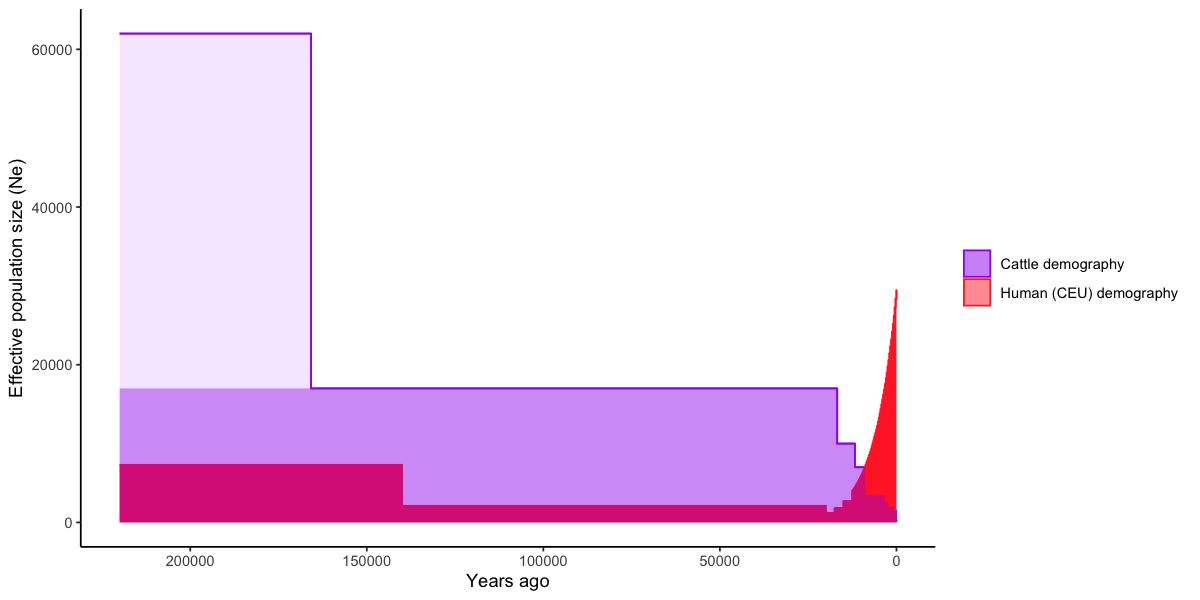

In [7]:
cattle_demo = data.frame(
    species = 'cattle',
    gen_ago = c(44000, 33154, 3354, 2354, 1754, 654, 454, 154, 24, 18, 12, 6, 3),
    Ne = c(6.2e4, 1.7e4, 1e4, 7e3, 3.5e3, 2.5e3, 2e3, 1.5e3, 1e3, 350, 250, 120, 90)
)
cattle_demo$years_ago = cattle_demo$gen_ago * 5

anc_pop = 7300
anc_gen_ago = 8800
ooa_pop = 2100
ooa_gen_ago = 5600
eu_as_gen_ago = 848
eu_as_pop = 1000
growth_rate = 0.004

human_ne = function(gen_ago) {
    if(gen_ago > ooa_gen_ago) {
        return(anc_pop)
    } else if (gen_ago <= ooa_gen_ago && gen_ago > eu_as_gen_ago) {
        return(ooa_pop)
    } else if (gen_ago <= eu_as_gen_ago) {
        return(eu_as_pop * (1+growth_rate)^(eu_as_gen_ago - gen_ago))
    }
}

human_demo = data.frame(
    species = 'human',
    gen_ago = c(seq(anc_gen_ago, 500, -100), seq(490, 0, -10))
)
human_demo$Ne = sapply(human_demo$gen_ago, human_ne)
human_demo$years_ago = human_demo$gen_ago * 25

demos = rbind(cattle_demo, human_demo)

# This is just a fast way to get the fill correct
shifted_cattle = cattle_demo[2:nrow(cattle_demo), c(1,4)]
shifted_cattle$years_ago = shifted_cattle$years_ago + 1
shifted_cattle$Ne = cattle_demo$Ne[1:(nrow(cattle_demo)-1)]

shifted_human = human_demo[2:nrow(human_demo), c(1,4)]
shifted_human$years_ago = shifted_human$years_ago + 1
shifted_human$Ne = human_demo$Ne[1:(nrow(human_demo)-1)]

boxes = rbind(
    demos %>% select(species, years_ago, Ne),
    shifted_cattle,
    shifted_human
)

fig_size(10,5)

# I have have this double plotted stuff to make part of the box paler
boxes = boxes %>% mutate(alp = ifelse(species=='cattle', 0.2, 0.5))
boxes2 = boxes %>% filter(species=='cattle') %>% mutate(Ne = ifelse(Ne == 62000, 17000, Ne), alp = 0.3)

boxes %>%
arrange(species, desc(years_ago)) %>%
ggplot(aes(x=years_ago, y=Ne, color=species, fill=species)) +
    scale_x_reverse() + geom_step(show.legend=F) + theme_classic() +
    xlab('Years ago') + ylab('Effective population size (Ne)') + theme(legend.title=element_blank()) +
    geom_area(position='identity', aes(alpha=alp)) +
    geom_area(data=boxes2, aes(x=years_ago, y=Ne, alpha=alp), color=NA, fill=color_key[['cattle']], show.legend=F) +
    scale_color_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
    scale_fill_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
    scale_alpha(guide='none') +
    guides(fill = guide_legend(override.aes = list(alpha = 0.5)))

# Worked examples

### What is on disk?

In [16]:
m <- build_manifest()

30 loadable run(s) in 12 arm(s):

                     arm           runs species gwas_x gtex_x  cmaf    fm   r2
 cmaf001_fm001_g5t20_2Mb E1,E2,E3,E4,E5  cattle      5     20 0.001 0.001 0.75
 cmaf001_fm001_g5t20_2Mb A1,A2,A3,A4,A5   human      5     20 0.001 0.001 0.75
  cmaf001_fm01_g5t20_2Mb E1,E2,E3,E4,E5  cattle      5     20 0.001 0.010 0.75
  cmaf001_fm01_g5t20_2Mb A1,A2,A3,A4,A5   human      5     20 0.001 0.010 0.75
           r2_25_10x_2Mb             E1  cattle     10     10 0.010    NA 0.25
            r2_25_1x_2Mb             E1  cattle      1      1 0.010    NA 0.25
           r2_25_20x_2Mb             E1  cattle     20     20 0.010    NA 0.25
           r2_25_35x_2Mb             E1  cattle     35     35 0.010    NA 0.25
            r2_25_5x_2Mb             E1  cattle      5      5 0.010    NA 0.25
           r2_75_10x_2Mb             E1  cattle     10     10 0.010    NA 0.75
            r2_75_1x_2Mb             E1  cattle      1      1 0.010    NA 0.75
           r2_75_2

### Set 2: GWAS 5x, GTEx 20x, causal floor 0.001, fine-mapping and GLM floor 0.01, r2 0.75

Five human replicates (A1–A5) and five cattle (E1–E5). This is the arm described by
`simulation_data/cmaf001_fm01_g5t20_2Mb/PROVENANCE.txt`.

In [9]:
Arare <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.001)
Erare <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.001)

matched 5 run(s): cmaf001_fm01_g5t20_2Mb/A1, cmaf001_fm01_g5t20_2Mb/A2, cmaf001_fm01_g5t20_2Mb/A3, cmaf001_fm01_g5t20_2Mb/A4, cmaf001_fm01_g5t20_2Mb/A5
[sig.out] 335 signal(s) read; 32 (9.6%) fell in no GWAS locus and were dropped
rows: enloc 1314 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf001_fm01_g5t20_2Mb/E1, cmaf001_fm01_g5t20_2Mb/E2, cmaf001_fm01_g5t20_2Mb/E3, cmaf001_fm01_g5t20_2Mb/E4, cmaf001_fm01_g5t20_2Mb/E5
[sig.out] 959 signal(s) read; 144 (15.0%) fell in no GWAS locus and were dropped
rows: enloc 1755 | traits 750 | leads 1250 | vars 19883


gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    32    29   114    75
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    79    37    28   106


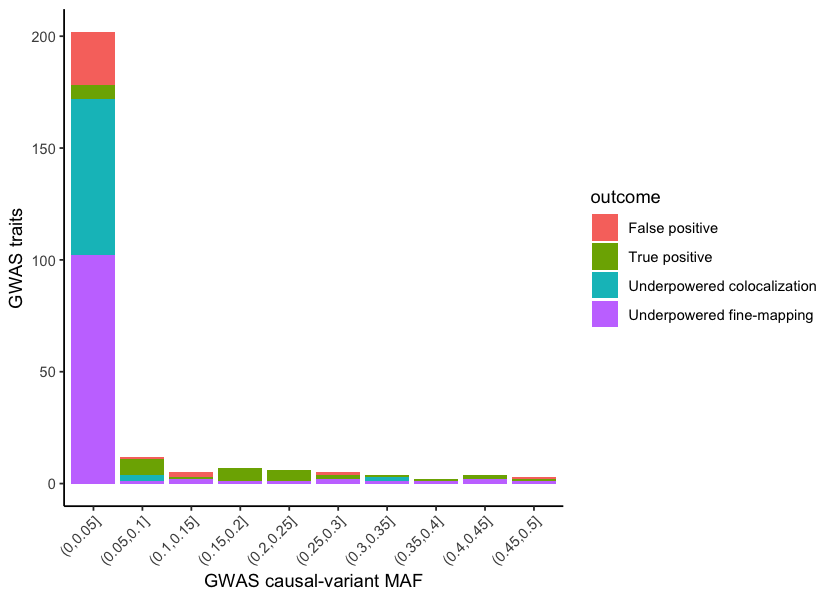

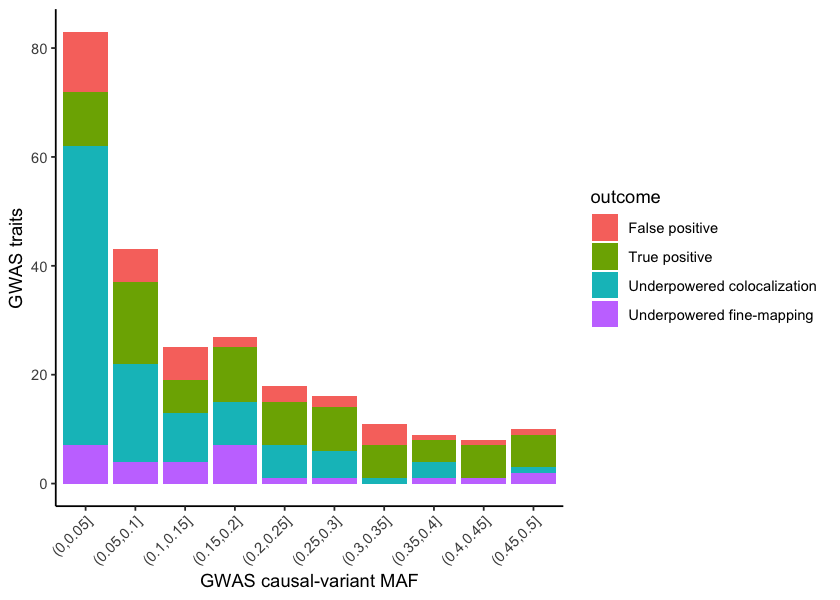

In [10]:
plot_enloc_outcomes(Arare, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(Erare, gtex_cat = 'gtex', rcp_cutoff = 0.5)

The 1000- and 500-individual eQTL panels, at both RCP thresholds. `tp` here reproduces
`enloc_pow_rcp50` / `enloc_pow_rcp90` in `simulation_data/coloc_summary_round3.tsv` exactly
(A: 32/26 and 21/17; E: 79/63 and 64/49), which is a useful check that the joins are right.
`fp` is not expected to match: this notebook keeps one best row per GWAS trait, while
`summarize_coloc.py` scores trait pairs.

In [11]:
for (gc in c('gtex', 'gtex_smaller')) {
    for (rcp in c(0.5, 0.9)) {
        plot_enloc_outcomes(Arare, gtex_cat = gc, rcp_cutoff = rcp, prnt = FALSE)
        plot_enloc_outcomes(Erare, gtex_cat = gc, rcp_cutoff = rcp, prnt = FALSE)
    }
}

gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    32    29   114    75
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    79    37    28   106
gtex, RCP > 0.9, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    26     4   114   106
gtex, RCP > 0.9, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    63    16    28   143
gtex_smaller, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    21    23   132    74
gtex_smaller, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    64    35    45   106
gtex_smaller, RCP > 0.9, GWAS p < 1: 250 G

### Allele-frequency and selection diagnostics

The cmaf arm is the only one with both species fetched locally, so it is the only place
this comparison can be made from raw files.

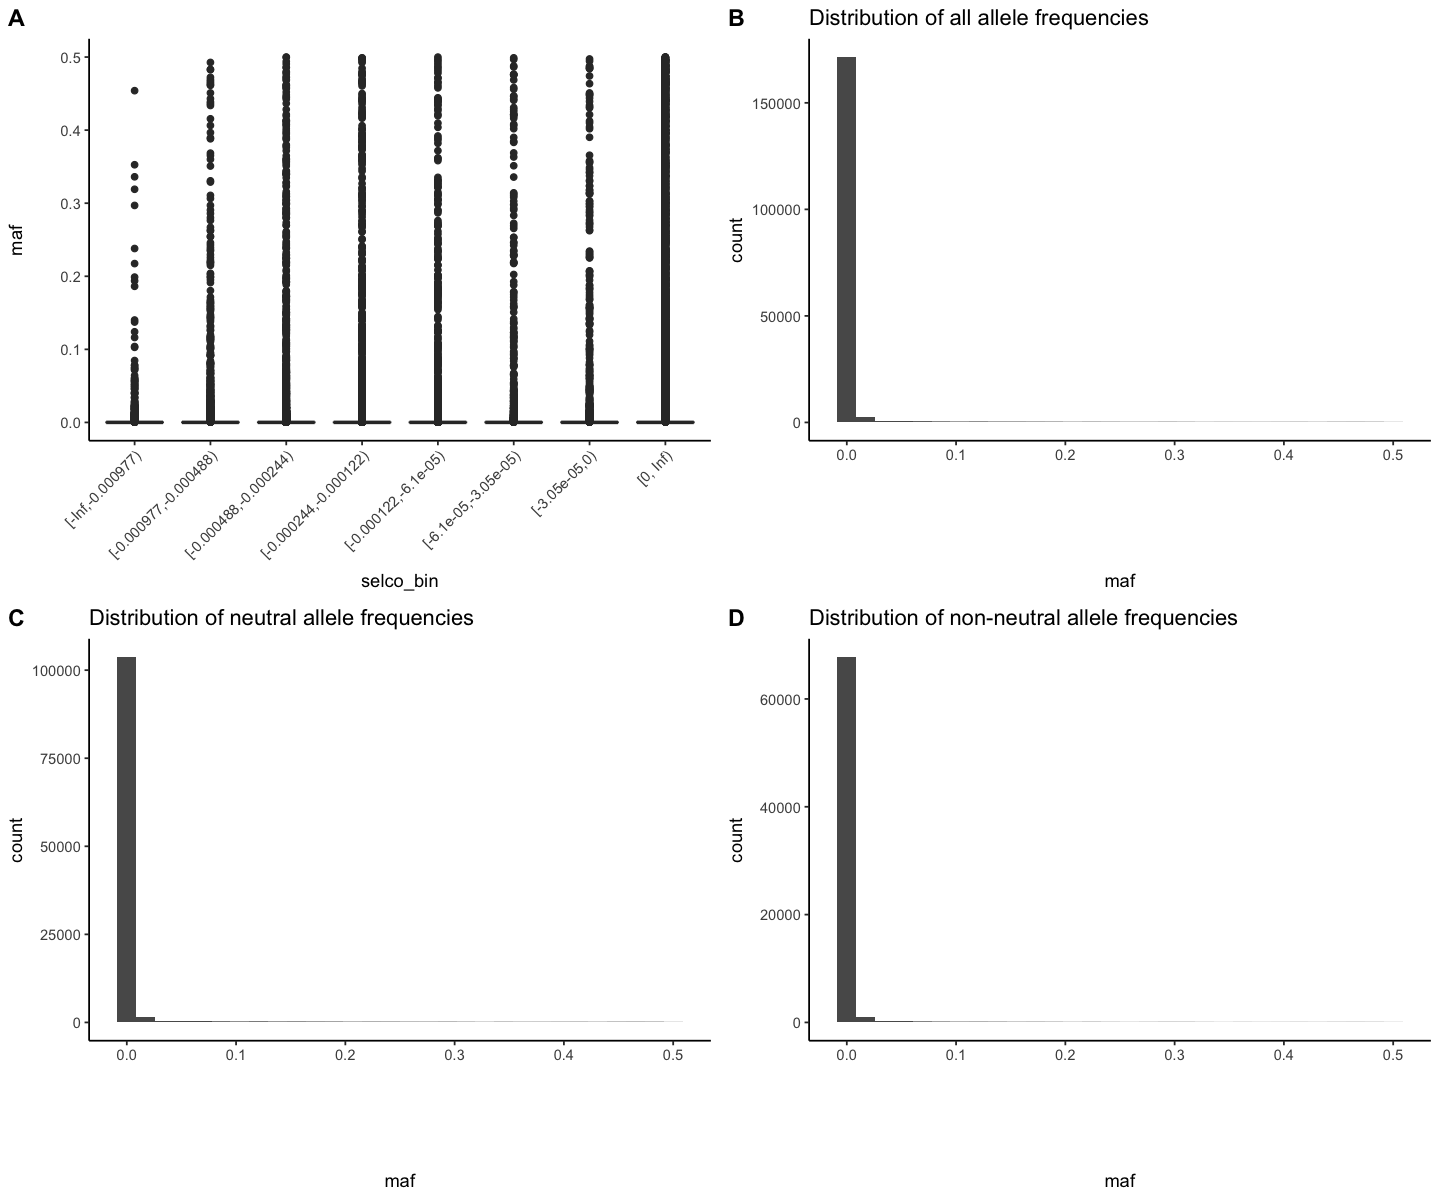

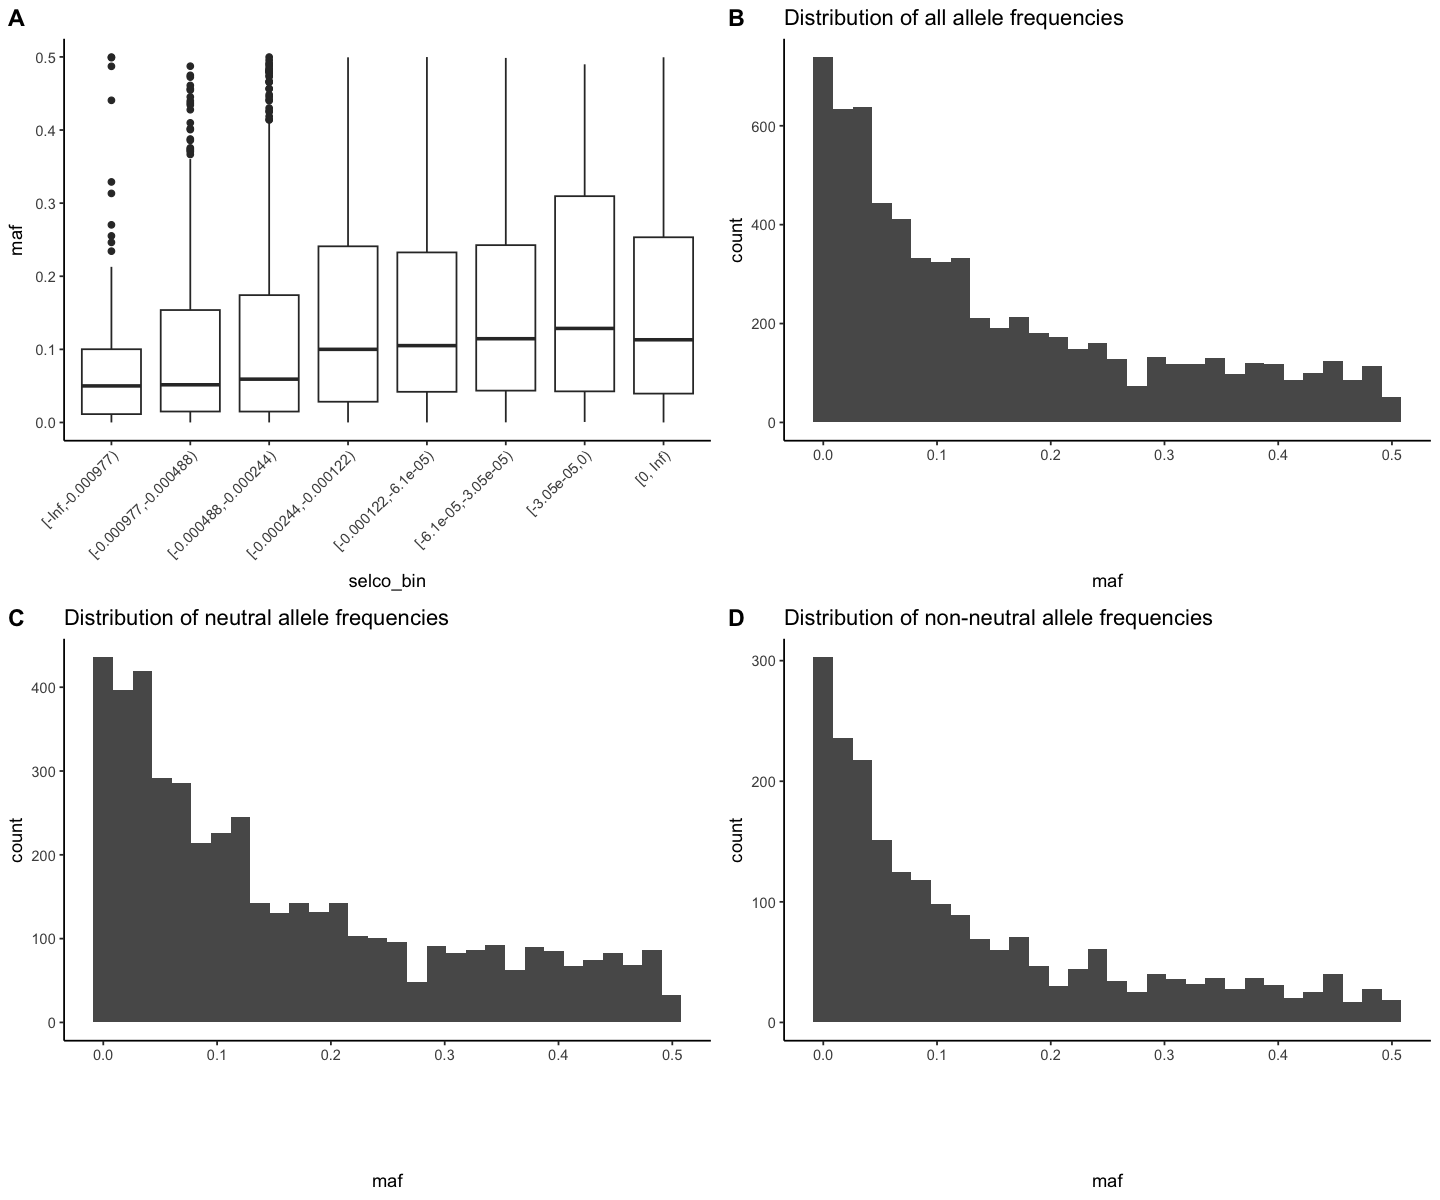

In [28]:
plot_selco_af(Arare)
plot_selco_af(Erare)

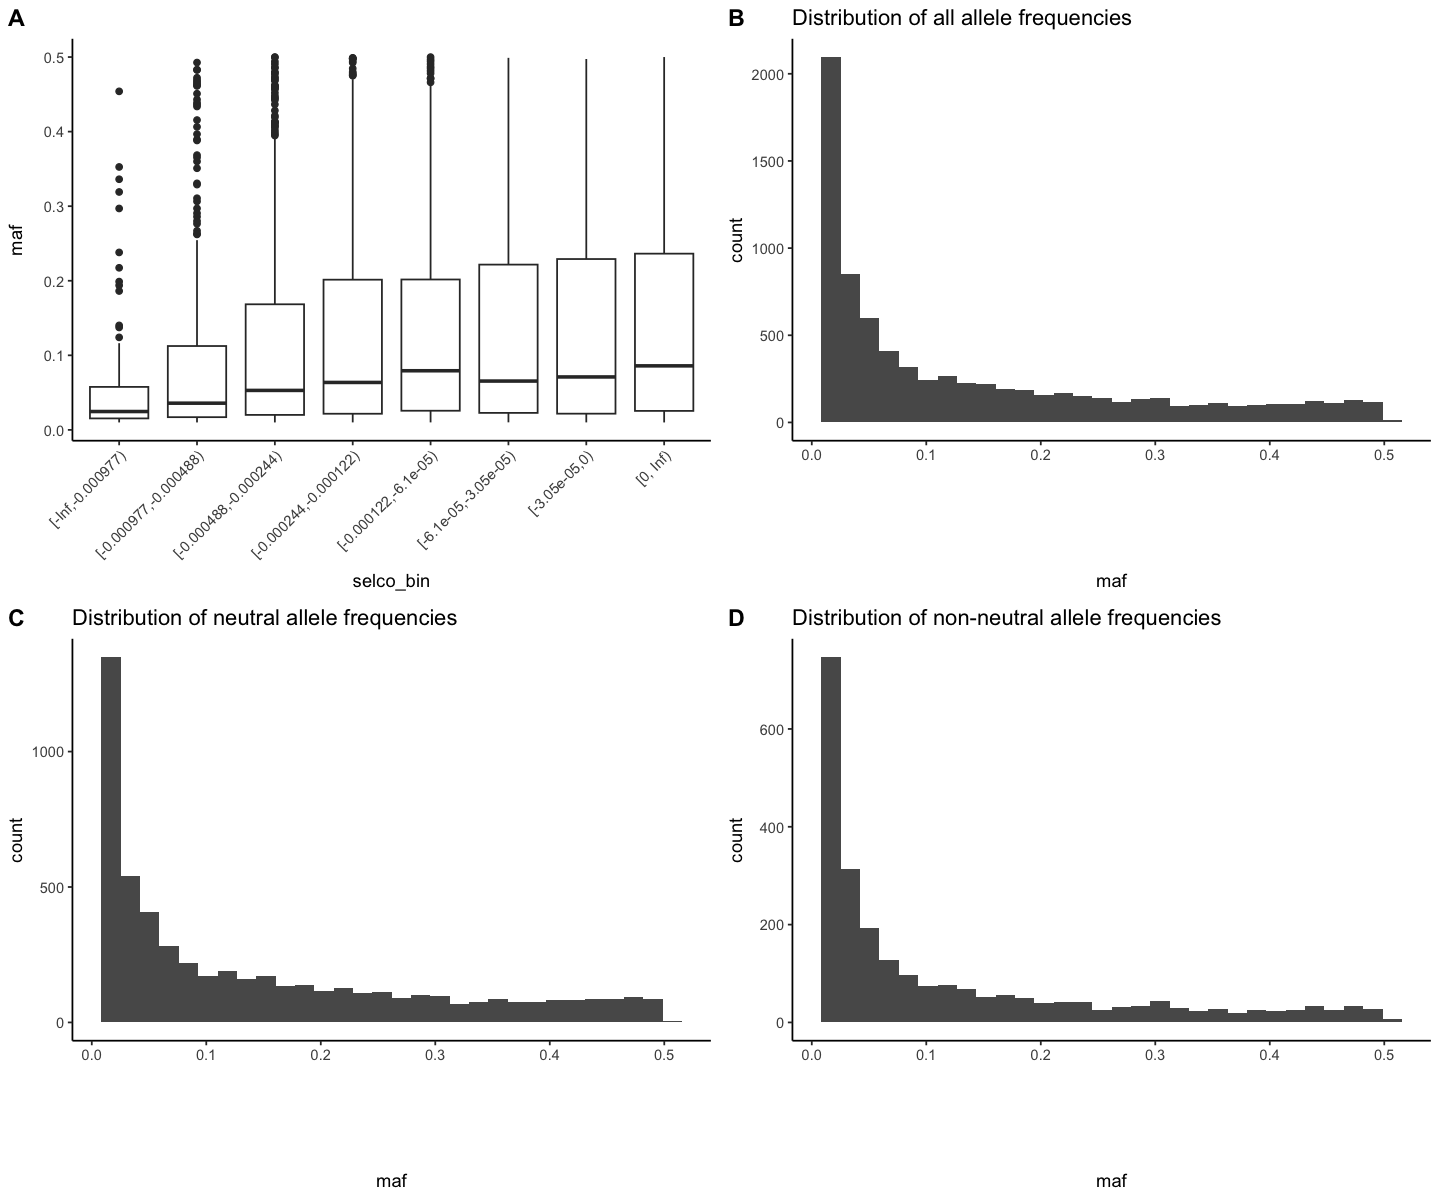

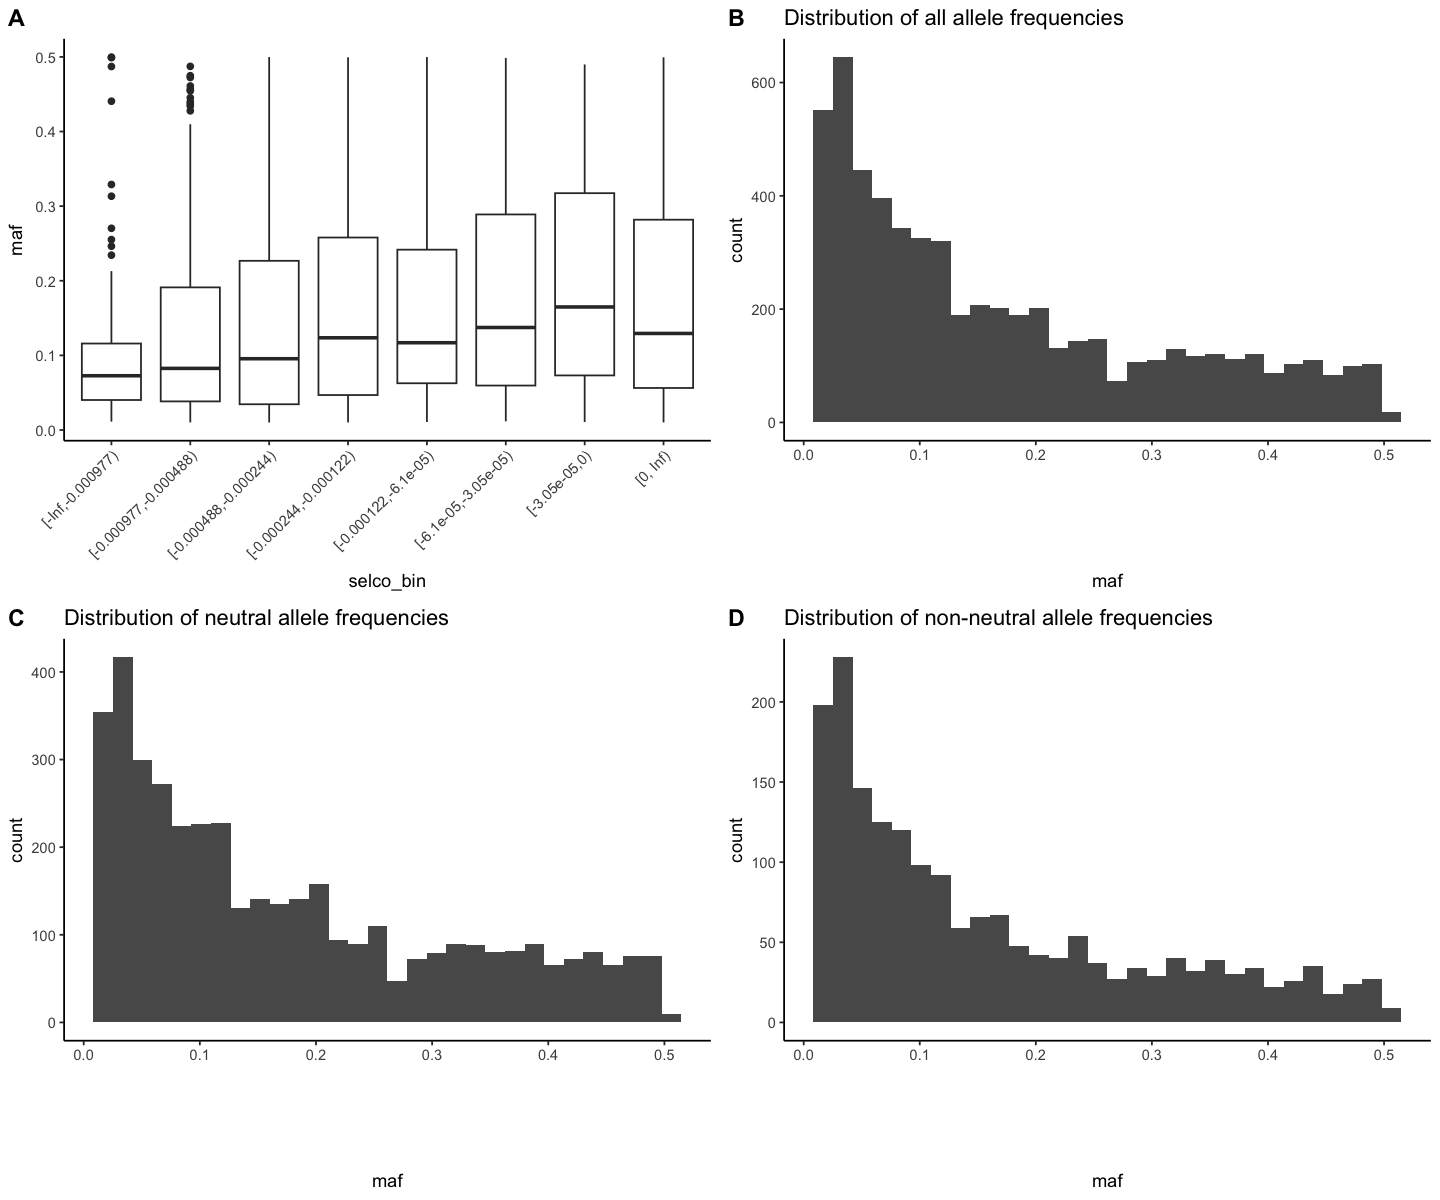

In [29]:
plot_selco_af(Arare, min_maf=0.01)
plot_selco_af(Erare, min_maf=0.01)

### Set 1: the multiplier grid

Only cattle (`E1`) was fetched for these arms — every `A1` directory is present but empty,
so `load_sims()` warns and skips it.

In [ ]:
grid <- load_sims(arm = c('r2_75_1x_2Mb', 'r2_75_5x_2Mb', 'r2_75_10x_2Mb',
                          'r2_75_20x_2Mb', 'r2_75_35x_2Mb'))
grid$enloc %>%
    count(arm, gwas_mult, gtex_category) %>%
    tidyr::pivot_wider(names_from = gtex_category, values_from = n)

# Results comparison

## Various multiplier comparisons, r2 0.75, causative variants and mapped variants > 1%

matched 5 run(s): cmaf01_fm01_g5t20_2Mb/A1, cmaf01_fm01_g5t20_2Mb/A2, cmaf01_fm01_g5t20_2Mb/A3, cmaf01_fm01_g5t20_2Mb/A4, cmaf01_fm01_g5t20_2Mb/A5
[sig.out] 398 signal(s) read; 35 (8.8%) fell in no GWAS locus and were dropped
rows: enloc 1329 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf01_fm01_g5t20_2Mb/E1, cmaf01_fm01_g5t20_2Mb/E2, cmaf01_fm01_g5t20_2Mb/E3, cmaf01_fm01_g5t20_2Mb/E4, cmaf01_fm01_g5t20_2Mb/E5
[sig.out] 926 signal(s) read; 117 (12.6%) fell in no GWAS locus and were dropped
rows: enloc 1758 | traits 750 | leads 1250 | vars 19883
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    62    27   112    49
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    80    42    24   104


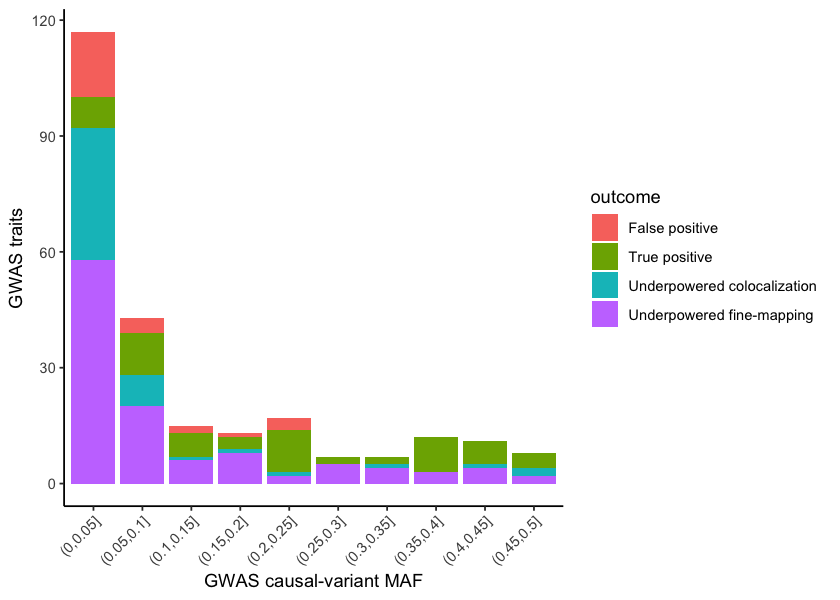

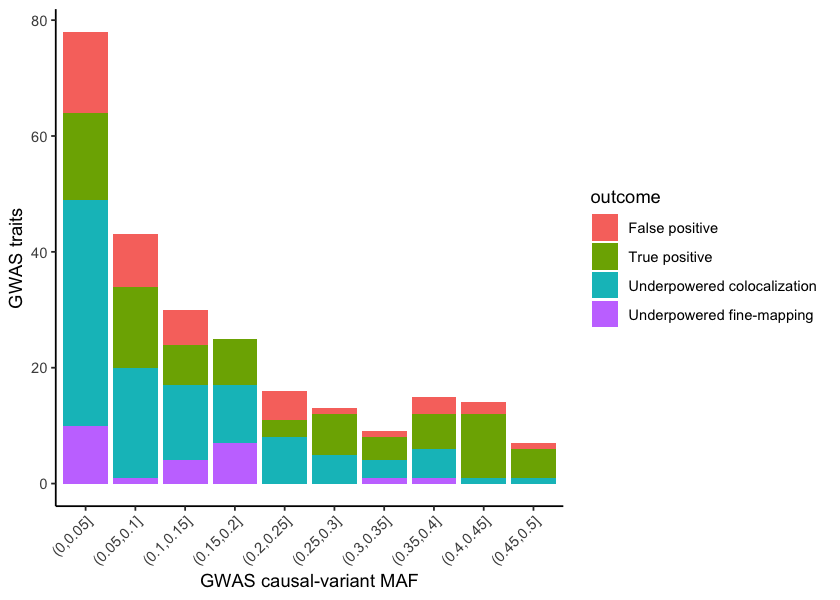

In [48]:
Acomm <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.01)
Ecomm <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.01)

plot_enloc_outcomes(Acomm, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(Ecomm, gtex_cat = 'gtex', rcp_cutoff = 0.5)

matched 5 run(s): cmaf01_fm01_g10t20_2Mb/A1, cmaf01_fm01_g10t20_2Mb/A2, cmaf01_fm01_g10t20_2Mb/A3, cmaf01_fm01_g10t20_2Mb/A4, cmaf01_fm01_g10t20_2Mb/A5
[sig.out] 466 signal(s) read; 34 (7.3%) fell in no GWAS locus and were dropped
rows: enloc 1323 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf01_fm01_g10t20_2Mb/E1, cmaf01_fm01_g10t20_2Mb/E2, cmaf01_fm01_g10t20_2Mb/E3, cmaf01_fm01_g10t20_2Mb/E4, cmaf01_fm01_g10t20_2Mb/E5
[sig.out] 986 signal(s) read; 84 (8.5%) fell in no GWAS locus and were dropped
rows: enloc 1793 | traits 750 | leads 1250 | vars 19883
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   103    19    73    55
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1   120    38    18    74


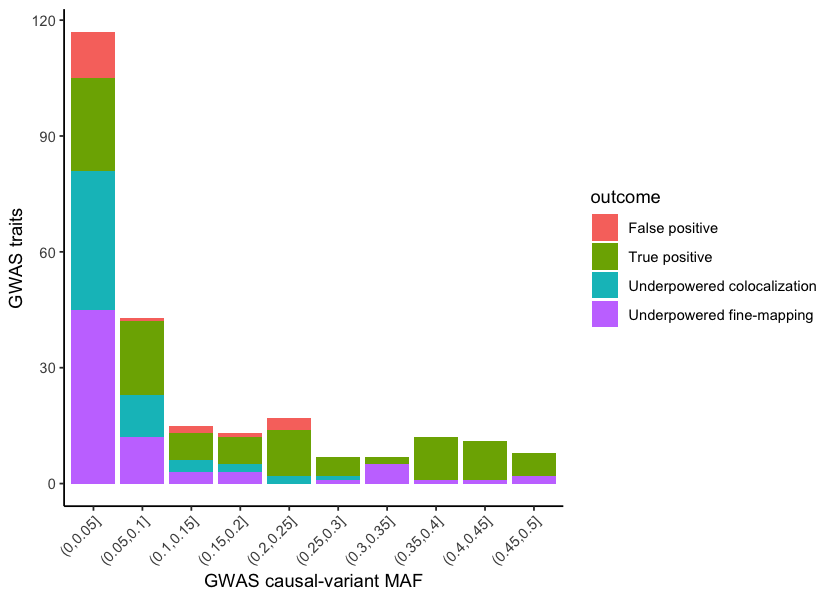

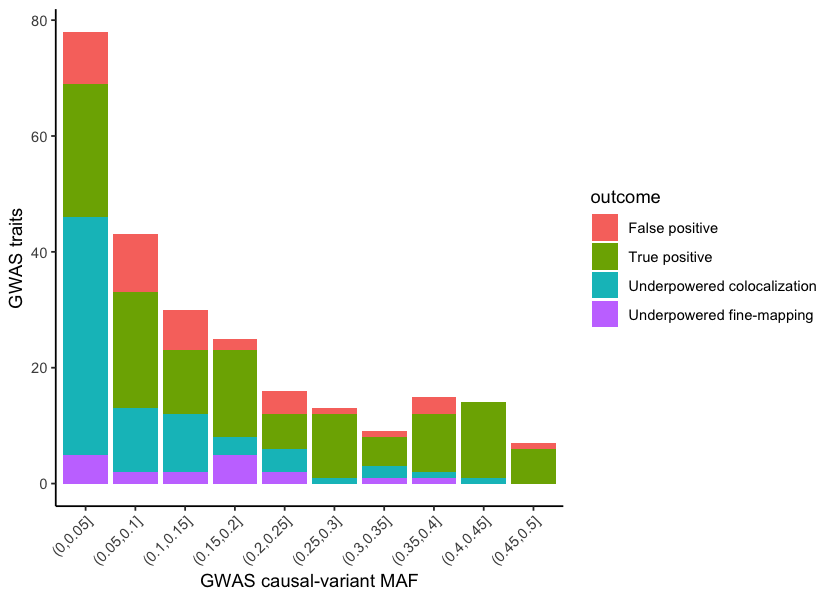

In [60]:
A1020 <- load_sims(sim_category = 'A', gwas_mult = 10, gtex_mult = 20, causal_min_maf = 0.01)
E1020 <- load_sims(sim_category = 'E', gwas_mult = 10, gtex_mult = 20, causal_min_maf = 0.01)

plot_enloc_outcomes(A1020, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(E1020, gtex_cat = 'gtex', rcp_cutoff = 0.5)

matched 5 run(s): cmaf01_fm01_g5t30_2Mb/A1, cmaf01_fm01_g5t30_2Mb/A2, cmaf01_fm01_g5t30_2Mb/A3, cmaf01_fm01_g5t30_2Mb/A4, cmaf01_fm01_g5t30_2Mb/A5
[sig.out] 459 signal(s) read; 39 (8.5%) fell in no GWAS locus and were dropped
rows: enloc 1330 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf01_fm01_g5t30_2Mb/E1, cmaf01_fm01_g5t30_2Mb/E2, cmaf01_fm01_g5t30_2Mb/E3, cmaf01_fm01_g5t30_2Mb/E4, cmaf01_fm01_g5t30_2Mb/E5
[sig.out] 1006 signal(s) read; 134 (13.3%) fell in no GWAS locus and were dropped
rows: enloc 1824 | traits 750 | leads 1250 | vars 19883
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    73    35    94    48
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    94    43    23    90


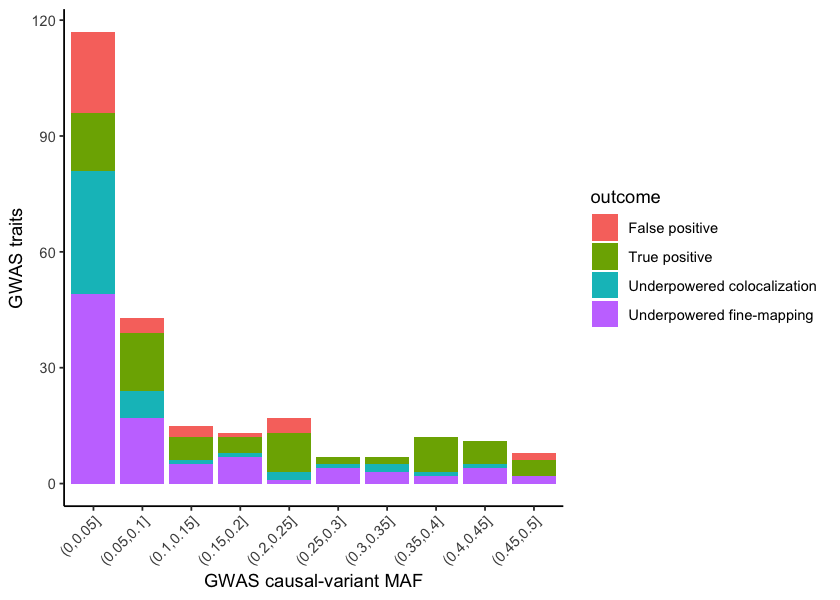

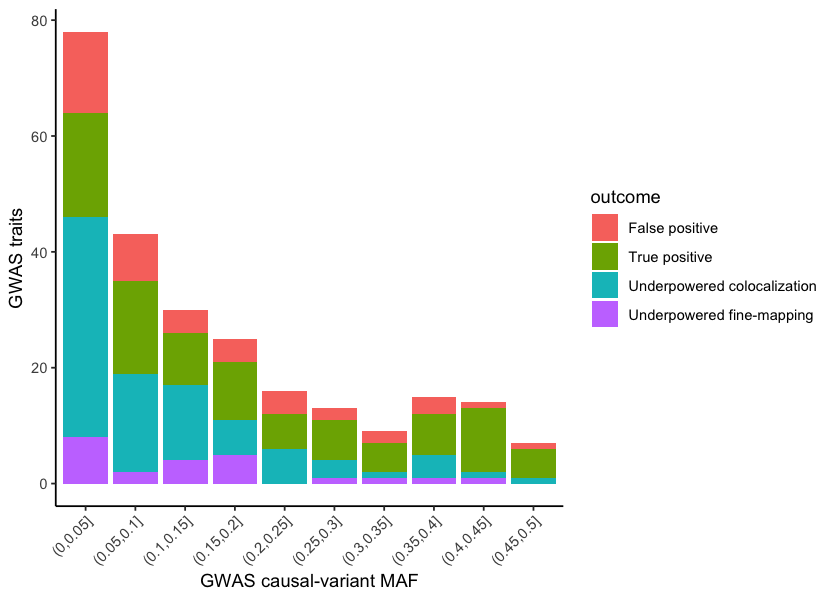

In [62]:
A530 <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 30, causal_min_maf = 0.01)
E530 <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 30, causal_min_maf = 0.01)

plot_enloc_outcomes(A530, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(E530, gtex_cat = 'gtex', rcp_cutoff = 0.5)

## GWAS 5x and GTEx 20x, r2 0.75

### Causative variants and mapped variants > 1%

matched 5 run(s): cmaf01_fm01_g5t20_2Mb/A1, cmaf01_fm01_g5t20_2Mb/A2, cmaf01_fm01_g5t20_2Mb/A3, cmaf01_fm01_g5t20_2Mb/A4, cmaf01_fm01_g5t20_2Mb/A5
[sig.out] 398 signal(s) read; 35 (8.8%) fell in no GWAS locus and were dropped
rows: enloc 1329 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf01_fm01_g5t20_2Mb/E1, cmaf01_fm01_g5t20_2Mb/E2, cmaf01_fm01_g5t20_2Mb/E3, cmaf01_fm01_g5t20_2Mb/E4, cmaf01_fm01_g5t20_2Mb/E5
[sig.out] 926 signal(s) read; 117 (12.6%) fell in no GWAS locus and were dropped
rows: enloc 1758 | traits 750 | leads 1250 | vars 19883
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    62    27   112    49
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    80    42    24   104


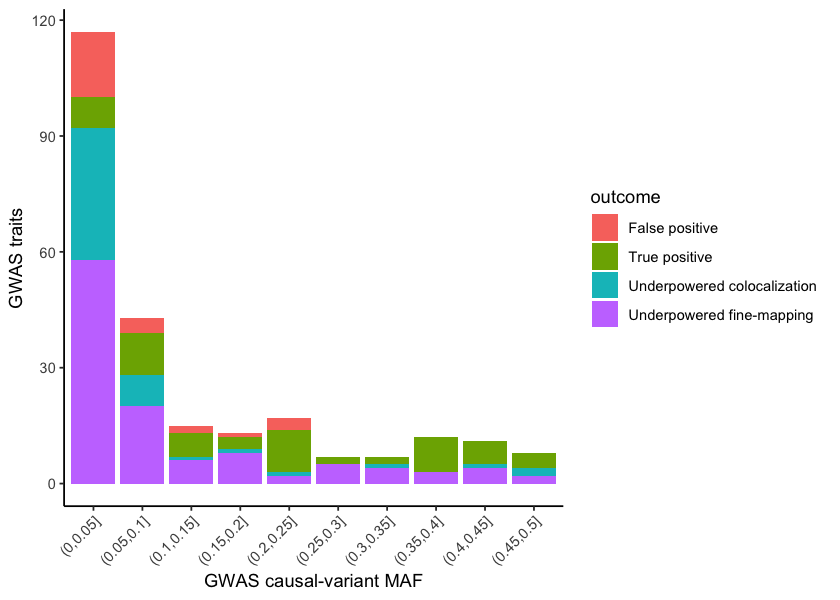

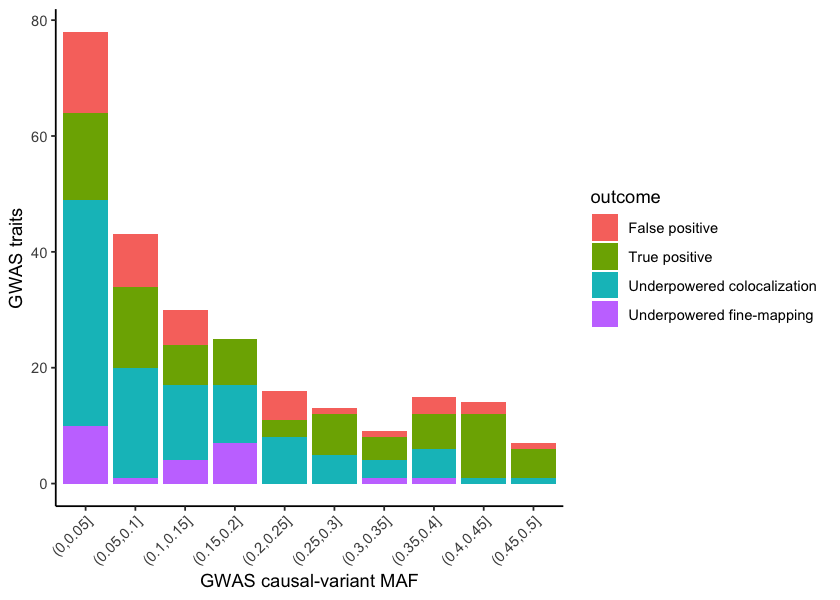

In [45]:
Acomm <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.01)
Ecomm <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.01)

plot_enloc_outcomes(Acomm, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(Ecomm, gtex_cat = 'gtex', rcp_cutoff = 0.5)

matched 5 run(s): cmaf01_fm01_g5t20_2Mb/A1, cmaf01_fm01_g5t20_2Mb/A2, cmaf01_fm01_g5t20_2Mb/A3, cmaf01_fm01_g5t20_2Mb/A4, cmaf01_fm01_g5t20_2Mb/A5
[sig.out] 398 signal(s) read; 35 (8.8%) fell in no GWAS locus and were dropped
rows: enloc 1329 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf01_fm01_g5t20_2Mb/E1, cmaf01_fm01_g5t20_2Mb/E2, cmaf01_fm01_g5t20_2Mb/E3, cmaf01_fm01_g5t20_2Mb/E4, cmaf01_fm01_g5t20_2Mb/E5
[sig.out] 926 signal(s) read; 117 (12.6%) fell in no GWAS locus and were dropped
rows: enloc 1758 | traits 750 | leads 1250 | vars 19883
gtex, RCP > 0.8, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    59    15   112    64
gtex, RCP > 0.8, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    67    28    24   131


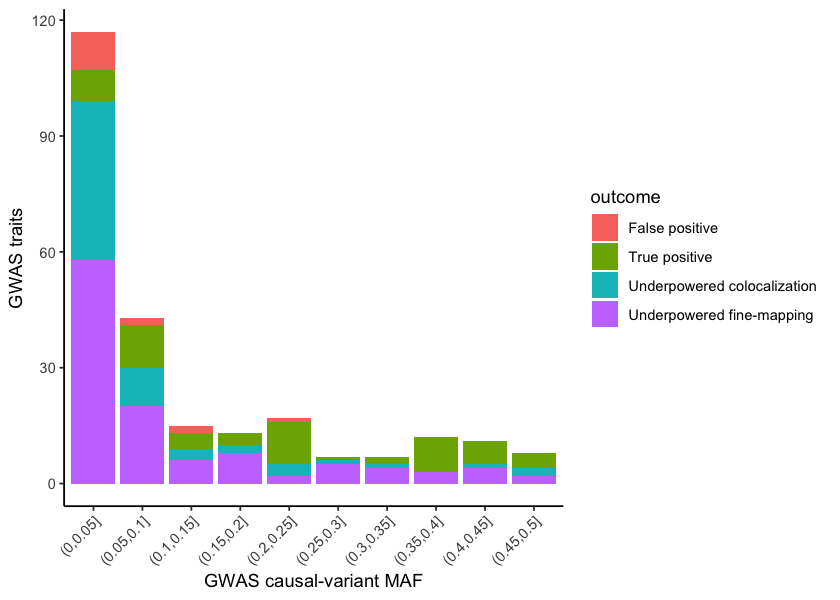

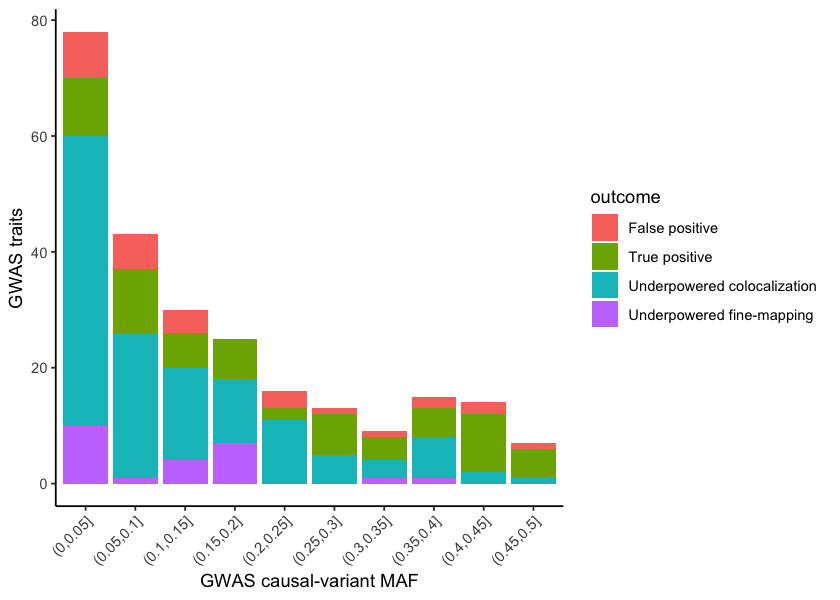

In [47]:
Acomm <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.01)
Ecomm <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.01)

plot_enloc_outcomes(Acomm, gtex_cat = 'gtex', rcp_cutoff = 0.8)
plot_enloc_outcomes(Ecomm, gtex_cat = 'gtex', rcp_cutoff = 0.8)

### Causative variants > 0.1% and mapped variants > 1%

matched 10 run(s): cmaf001_fm001_g5t20_2Mb/A1, cmaf001_fm001_g5t20_2Mb/A2, cmaf001_fm001_g5t20_2Mb/A3, cmaf001_fm001_g5t20_2Mb/A4, cmaf001_fm001_g5t20_2Mb/A5, cmaf001_fm01_g5t20_2Mb/A1, cmaf001_fm01_g5t20_2Mb/A2, cmaf001_fm01_g5t20_2Mb/A3, cmaf001_fm01_g5t20_2Mb/A4, cmaf001_fm01_g5t20_2Mb/A5
[sig.out] 479 signal(s) read; 62 (12.9%) fell in no GWAS locus and were dropped
rows: enloc 2720 | traits 1500 | leads 2500 | vars 549394
matched 10 run(s): cmaf001_fm001_g5t20_2Mb/E1, cmaf001_fm001_g5t20_2Mb/E2, cmaf001_fm001_g5t20_2Mb/E3, cmaf001_fm001_g5t20_2Mb/E4, cmaf001_fm001_g5t20_2Mb/E5, cmaf001_fm01_g5t20_2Mb/E1, cmaf001_fm01_g5t20_2Mb/E2, cmaf001_fm01_g5t20_2Mb/E3, cmaf001_fm01_g5t20_2Mb/E4, cmaf001_fm01_g5t20_2Mb/E5
[sig.out] 1843 signal(s) read; 305 (16.5%) fell in no GWAS locus and were dropped
rows: enloc 3337 | traits 1500 | leads 2500 | vars 39766
gtex, RCP > 0.5, GWAS p < 1: 500 GWAS trait(s) over 10 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    

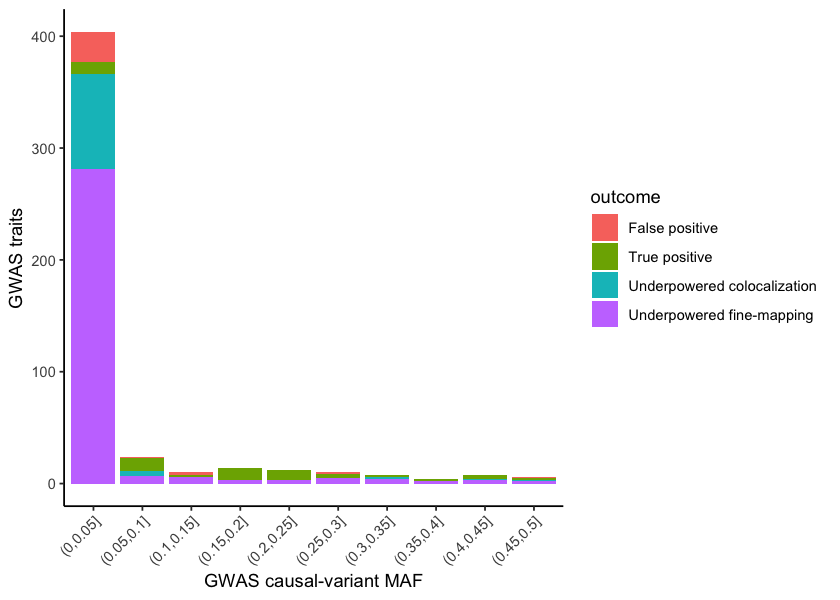

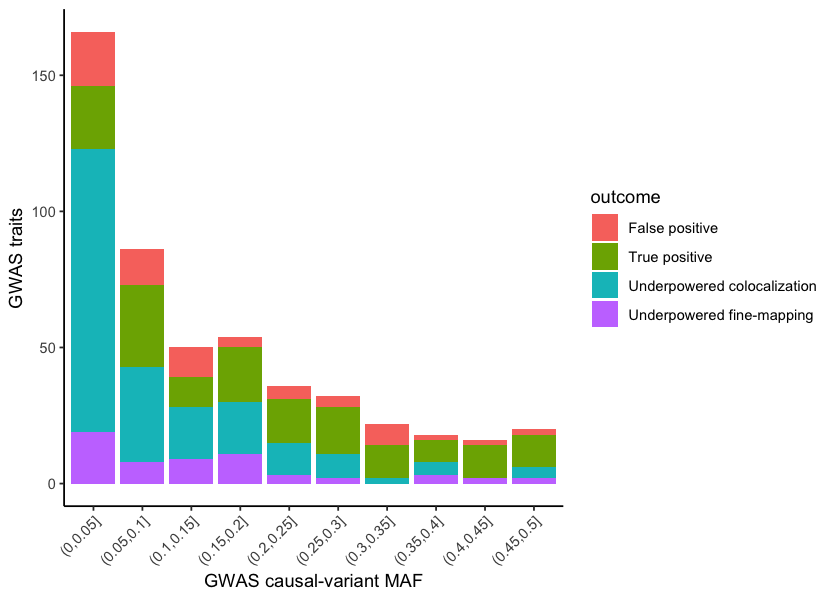

In [31]:
Arare <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.001)
Erare <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.001)

plot_enloc_outcomes(Arare, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(Erare, gtex_cat = 'gtex', rcp_cutoff = 0.5)

### Causative variants and mapped variants > 0.1%

matched 5 run(s): cmaf001_fm001_g5t20_2Mb/A1, cmaf001_fm001_g5t20_2Mb/A2, cmaf001_fm001_g5t20_2Mb/A3, cmaf001_fm001_g5t20_2Mb/A4, cmaf001_fm001_g5t20_2Mb/A5
[sig.out] 144 signal(s) read; 30 (20.8%) fell in no GWAS locus and were dropped
rows: enloc 1406 | traits 750 | leads 1250 | vars 274697
matched 5 run(s): cmaf001_fm001_g5t20_2Mb/E1, cmaf001_fm001_g5t20_2Mb/E2, cmaf001_fm001_g5t20_2Mb/E3, cmaf001_fm001_g5t20_2Mb/E4, cmaf001_fm001_g5t20_2Mb/E5
[sig.out] 884 signal(s) read; 161 (18.2%) fell in no GWAS locus and were dropped
rows: enloc 1582 | traits 750 | leads 1250 | vars 19883
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    27     3   202    18
gtex, RCP > 0.5, GWAS p < 1: 250 GWAS trait(s) over 5 run(s)
# A tibble: 1 × 4
     tp    fp   ufm    uc
  <int> <int> <int> <int>
1    82    34    31   103


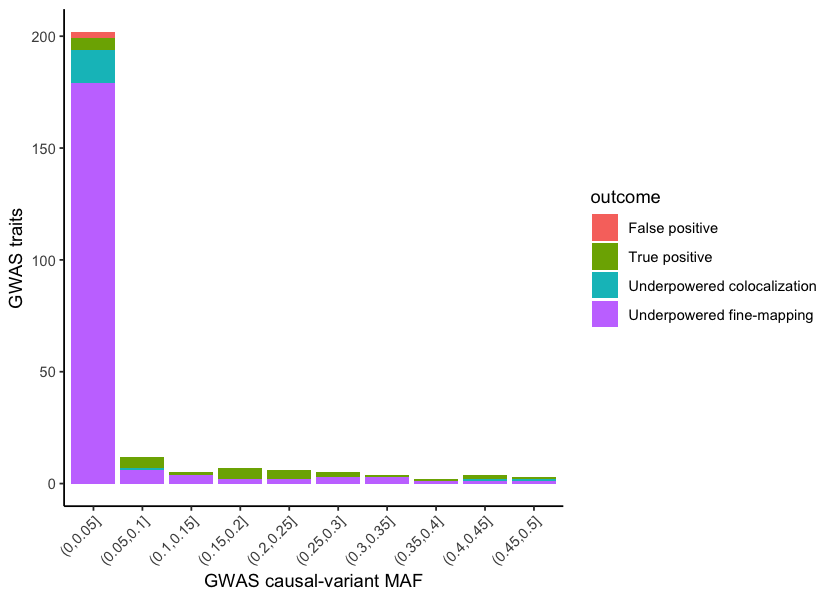

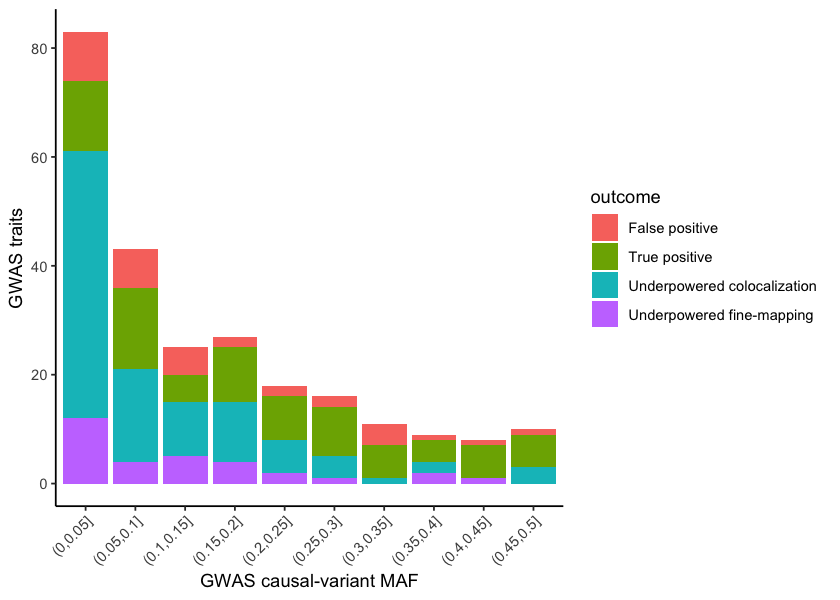

In [30]:
A3 <- load_sims(sim_category = 'A', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.001, fm_min_maf=0.001)
E3 <- load_sims(sim_category = 'E', gwas_mult = 5, gtex_mult = 20, causal_min_maf = 0.001, fm_min_maf=0.001)

plot_enloc_outcomes(A3, gtex_cat = 'gtex', rcp_cutoff = 0.5)
plot_enloc_outcomes(E3, gtex_cat = 'gtex', rcp_cutoff = 0.5)

# Precision-recall and the simulation report

In [ ]:
# Both species of one arm in a single object -> one PRC line each.
d <- load_sims(arm = 'cmaf01_fm01_g5t20_2Mb')

# Colour = species, solid vs dashed = all traits vs the loci a 100k GWAS would
# find. One panel per eQTL panel size.
plot_prc(d, gtex_cat = 'gtex', overlay_gwas_n = GWAS_N_DEFAULT)

# Or both panel sizes side by side under one shared key, as the report lays it out:
pr <- prc_panel_row(d, overlay_gwas_n = GWAS_N_DEFAULT, base_size = 9)
fig_size(10, 4); plot_grid(pr$panels, pr$key, ncol = 1, rel_heights = c(1, 0.16))

Solid lines are all GWAS traits, dotted are the loci a 100,000-person GWAS would
find. Restricting to those changes the comparison substantially: recall is a fraction of a much
smaller, much more findable set of traits.

In [ ]:
generate_simulation_report(d)          # -> simulation_data/simulation_summaries/<arm>.pdf